# Preparación de Gold: inteligencia de columnas, calidad y estrategia de unión

Este notebook sigue una lectura ejecutiva. Cada bloque abre con lo que se va a revisar, continúa con el análisis y cierra con una interpretación concreta para decidir qué columnas conservar, cuáles limpiar y qué entidades conviene unir.

El objetivo es convertir la exploración en una decisión de diseño: Bronze aporta la materia prima, Silver muestra el grano real de los registros y el cierre deja definida la base para Gold.

In [1]:
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import seaborn as sns
except ImportError:
    sns = None

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

if sns is not None:
    sns.set_theme(style='whitegrid', context='talk')

pd.set_option('display.max_columns', 250)
pd.set_option('display.max_colwidth', 120)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
NOTEBOOK_OUTPUT = PROJECT_ROOT / 'notebooks' / 'output'
BRONZE_EDA_CSV = NOTEBOOK_OUTPUT / 'bronze_twitter_eda.csv'
SILVER_EDA_CSV = NOTEBOOK_OUTPUT / 'silver_eda.csv'

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'BRONZE_EDA_CSV = {BRONZE_EDA_CSV}')
print(f'SILVER_EDA_CSV = {SILVER_EDA_CSV}')


def ensure_loaded() -> tuple[pd.DataFrame, pd.DataFrame]:
    global bronze_df, silver_df
    if 'bronze_df' not in globals():
        bronze_df = load_csv(BRONZE_EDA_CSV)
    if 'silver_df' not in globals():
        silver_df = load_csv(SILVER_EDA_CSV)
    return bronze_df, silver_df


def add_datetime_features(df: pd.DataFrame, column: str, target_name: str) -> pd.DataFrame:
    result = df.copy()
    if column in result.columns:
        result[column] = pd.to_datetime(result[column], errors='coerce', format='mixed')
        result[target_name] = result[column].dt.date.astype('string')
    return result


def section(title: str, subtitle: str | None = None) -> None:
    lines = [f'## {title}']
    if subtitle:
        lines.append(subtitle)
    display(Markdown('\n\n'.join(lines)))


def audit_frame(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_ratio': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
        'nunique': [df[col].nunique(dropna=True) for col in df.columns],
    }).sort_values(['missing_ratio', 'column'], ascending=[False, True])


def quality_summary(df: pd.DataFrame, id_col: str | None = None, text_col: str | None = None, date_col: str | None = None) -> pd.DataFrame:
    summary = {
        'rows': len(df),
        'columns': len(df.columns),
        'duplicate_rows': int(df.duplicated().sum()),
        'duplicate_rate': float(df.duplicated().mean()) if len(df) else 0.0,
    }
    if id_col and id_col in df.columns:
        summary['id_null_rate'] = float(df[id_col].isna().mean())
        summary['id_unique_rate'] = float(df[id_col].nunique(dropna=True) / len(df)) if len(df) else 0.0
    if text_col and text_col in df.columns:
        text_series = df[text_col].fillna('').astype('string')
        summary['text_missing_rate'] = float((text_series.str.len() == 0).mean())
        summary['avg_text_length'] = float(text_series.str.len().mean())
    if date_col and date_col in df.columns:
        summary['date_missing_rate'] = float(pd.to_datetime(df[date_col], errors='coerce', format='mixed').isna().mean())
    return pd.DataFrame([summary]).T.rename(columns={0: 'value'})


def top_values(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame()
    return df[column].fillna('Unknown').value_counts(dropna=False).head(n).to_frame('rows')


def safe_ratio(numerator: int, denominator: int) -> float:
    return float(numerator / denominator) if denominator else 0.0


def plot_missingness(df: pd.DataFrame, top_n: int = 15, title: str = '') -> None:
    audit = audit_frame(df).head(top_n).iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.4 * len(audit) + 2)))
    if sns is not None:
        sns.barplot(data=audit, x='missing_ratio', y='column', color='#2563eb')
    else:
        plt.barh(audit['column'], audit['missing_ratio'], color='#2563eb')
    plt.title(title or 'Columnas con más nulos')
    plt.xlabel('Proporción de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()


def plot_numeric_corr(df: pd.DataFrame, columns: list[str], title: str = '') -> None:
    numeric = [column for column in columns if column in df.columns]
    if len(numeric) < 2:
        print('No hay suficientes columnas numéricas para calcular la correlación.')
        return

    numeric_df = df[numeric].apply(pd.to_numeric, errors='coerce')
    corr = numeric_df.corr(numeric_only=True).round(2)
    if corr.empty:
        print('La matriz de correlación está vacía.')
        return

    label_map = {
        'tweet_retweetCount': 'rt',
        'tweet_replyCount': 'rep',
        'tweet_likeCount': 'like',
        'tweet_quoteCount': 'quote',
        'tweet_viewCount': 'views',
        'tweet_author_followers': 'followers',
        'tweet_author_following': 'following',
        'tweet_author_mediaCount': 'media',
        'tweet_author_favouritesCount': 'favs',
        'text_length': 'txt_len',
        'clean_text_length': 'clean_len',
    }
    corr.columns = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.columns]
    corr.index = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.index]

    mask = np.triu(np.ones_like(corr, dtype=bool))
    size = max(7.0, 0.85 * len(corr.columns) + 3.0)
    annot = len(corr.columns) <= 12

    plt.figure(figsize=(size, size))
    if sns is not None:
        sns.heatmap(
            corr,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.6,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            annot=annot,
            fmt='.2f',
            annot_kws={'size': 8},
        )
    else:
        masked = np.ma.masked_where(mask, corr.values)
        plt.imshow(masked, cmap='RdBu_r', vmin=-1, vmax=1)
        plt.colorbar(label='Correlación', shrink=0.8)
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=35, ha='right')
        plt.yticks(range(len(corr.index)), corr.index)

    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.title(title or 'Matriz de correlación')
    plt.tight_layout()
    plt.show()


def plot_top_categories(df: pd.DataFrame, column: str, top_n: int = 10, title: str = '') -> None:
    if column not in df.columns:
        print(f'{column} no existe en el dataframe.')
        return
    values = df[column].fillna('Unknown').value_counts(dropna=False).head(top_n).sort_values()
    plt.figure(figsize=(11, max(5, 0.4 * len(values) + 2)))
    if sns is not None:
        sns.barplot(x=values.values, y=values.index, color='#0f766e')
    else:
        plt.barh(values.index, values.values, color='#0f766e')
    plt.title(title or f'Top {top_n} valores para {column}')
    plt.xlabel('Registros')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


def plot_time_series(df: pd.DataFrame, date_col: str, title: str = '') -> None:
    if date_col not in df.columns:
        print(f'{date_col} no existe en el dataframe.')
        return
    series = pd.to_datetime(df[date_col], errors='coerce', format='mixed').dt.date.value_counts().sort_index()
    if series.empty:
        print(f'No hay fechas válidas en {date_col}.')
        return
    plt.figure(figsize=(12, 5))
    plt.plot(series.index, series.values, marker='o', color='#7c3aed')
    plt.title(title or f'Volumen en el tiempo por {date_col}')
    plt.xlabel('Fecha')
    plt.ylabel('Registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

PROJECT_ROOT = /home/naciscric/Documents/Data-Analysis-Programming
BRONZE_EDA_CSV = /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/bronze_twitter_eda.csv
SILVER_EDA_CSV = /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/silver_eda.csv


In [5]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return pd.read_csv(path)

def preview_frame(df: pd.DataFrame, title: str, max_rows: int = 5) -> None:
    display(Markdown(f'## {title}'))
    display(pd.DataFrame({'rows': [len(df)], 'columns': [len(df.columns)]}))
    display(df.head(max_rows))

def audit_frame(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_ratio': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
        'nunique': [df[col].nunique(dropna=True) for col in df.columns],
    }).sort_values(['missing_ratio', 'column'], ascending=[False, True])

def summarize_numeric(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include='number')
    if numeric_cols.empty:
        return pd.DataFrame()
    return numeric_cols.describe().T

def top_values(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame()
    return df[column].value_counts(dropna=False).head(n).to_frame('rows')

def candidate_columns(df: pd.DataFrame, max_missing: float = 0.35) -> list[str]:
    audit = audit_frame(df)
    keep = audit.loc[audit['missing_ratio'] <= max_missing, 'column'].tolist()
    return keep

## 1. Bronze: alcance y criterio de revisión

- **Qué analiza:** texto original, autor, fecha, idioma y señales de interacción.
- **Por qué importa:** aquí se define la base real para sentimiento, percepción y series de tiempo.
- **Objetivo ejecutivo:** separar señales analíticas de metadata operativa antes de construir Gold.

In [6]:
bronze_df = load_csv(BRONZE_EDA_CSV)
preview_frame(bronze_df, 'Bronze CSV')
display(audit_frame(bronze_df).head(40))
display(summarize_numeric(bronze_df))

## Bronze CSV

,rows,columns
0,412,31


,snapshot_bronze_file,snapshot__id,snapshot_has_next_page,snapshot_next_cursor,tweet_id,tweet_text,tweet_createdAt,tweet_lang,tweet_source,tweet_retweetCount,tweet_replyCount,tweet_likeCount,tweet_quoteCount,tweet_viewCount,tweet_isReply,tweet_conversationId,tweet_author_userName,tweet_author_name,tweet_author_id,tweet_author_followers,tweet_author_following,tweet_author_isVerified,tweet_author_isBlueVerified,tweet_author_location,tweet_author_createdAt,tweet_text_raw,clean_text,text_length,detected_lang,is_english,lang_match
0,twitter_tweets_20260411_024745.json,69d86f08aae727ea3c009a31,True,DAADDAABCgABHFg4fD4bQbEKAAIcSlokVJpQ7AAIAAIAAAACCAADAAAAAAgABAAAAAAKAAUcWDkr4gAnEAoABhxYOSvh_9jwAAA,2.042445e+18,Hey iPhone battery replacers! \n\niPhone 13 - 4 years old. Battery percentage at 76%\n\nContemplating battery replac...,Fri Apr 10 03:28:19 +0000 2026,en,Twitter for iPhone,0.0,0.0,1.0,0.0,31.0,False,2.042445e+18,ProfessorCardz,Professor Cardz,1.612073e+18,14119.0,645.0,False,True,New Delhi,Sun Jan 08 13:07:44 +0000 2023,Hey iPhone battery replacers! \n\niPhone 13 - 4 years old. Battery percentage at 76%\n\nContemplating battery replac...,Hey iPhone battery replacers! iPhone 13 - 4 years old. Battery percentage at 76% Contemplating battery replacement. ...,144,en,True,True
1,twitter_tweets_20260411_024745.json,69d86f08aae727ea3c009a31,True,DAADDAABCgABHFg4fD4bQbEKAAIcSlokVJpQ7AAIAAIAAAACCAADAAAAAAgABAAAAAAKAAUcWDkr4gAnEAoABhxYOSvh_9jwAAA,2.042356e+18,"@SamsungIndia @SamsungSupport\nVery disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the la...",Thu Apr 09 21:37:54 +0000 2026,en,Twitter for iPhone,0.0,0.0,1.0,0.0,29.0,False,2.042356e+18,MarghubR16168,marghub rahman,1.722152e+18,0.0,10.0,False,False,NaN,Wed Nov 08 07:22:23 +0000 2023,"@SamsungIndia @SamsungSupport\nVery disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the la...","Very disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the latest update, a green line appea...",238,en,True,True
2,twitter_tweets_20260411_024745.json,69d86f08aae727ea3c009a31,True,DAADDAABCgABHFg4fD4bQbEKAAIcSlokVJpQ7AAIAAIAAAACCAADAAAAAAgABAAAAAAKAAUcWDkr4gAnEAoABhxYOSvh_9jwAAA,2.041877e+18,"After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...",Wed Apr 08 13:54:51 +0000 2026,en,Twitter for iPhone,21.0,38.0,657.0,1.0,52175.0,False,2.041877e+18,VerdeSelvans,Bradley,1.303370e+18,7087.0,851.0,False,True,DIVE,Tue Sep 08 16:28:23 +0000 2020,"After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...","After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...",519,en,True,True
3,twitter_tweets_20260411_024745.json,69d86f08aae727ea3c009a31,True,DAADDAABCgABHFg4fD4bQbEKAAIcSlokVJpQ7AAIAAIAAAACCAADAAAAAAgABAAAAAAKAAUcWDkr4gAnEAoABhxYOSvh_9jwAAA,2.041655e+18,"The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impr...",Tue Apr 07 23:10:00 +0000 2026,en,Twitter for iPhone,0.0,0.0,0.0,0.0,29.0,False,2.041655e+18,DaveTaylor,Dave Taylor,9.973392e+06,13253.0,764.0,False,True,"Boulder, CO",Mon Nov 05 17:56:51 +0000 2007,"The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impr...","The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impre...",232,en,True,True
4,twitter_tweets_20260411_024745.json,69d86f08aae727ea3c009a31,True,DAADDAABCgABHFg4fD4bQbEKAAIcSlokVJpQ7AAIAAIAAAACCAADAAAAAAgABAAAAAAKAAUcWDkr4gAnEAoABhxYOSvh_9jwAAA,2.041073e+18,- Nokia 7210 Supernova (loved the speaker and the speaker accessories on this)\n- Nokia X2 (music buttons)\n- Moto E...,Mon Apr 06 08:36:26 +0000 2026,en,Twitter for iPhone,0.0,0.0,2.0,0.0,229.0,False,2.041073e+18,spydercut,batman,1.185079e+18,1057.0,3

,column,dtype,missing_ratio,non_null_count,nunique
23,tweet_author_location,str,0.381068,255,67
3,snapshot_next_cursor,str,0.174757,340,4
2,snapshot_has_next_page,object,0.145631,352,2
26,clean_text,str,0.029126,400,105
24,tweet_author_createdAt,str,0.029126,400,104
19,tweet_author_followers,float64,0.029126,400,112
20,tweet_author_following,float64,0.029126,400,114
18,tweet_author_id,float64,0.029126,400,104
22,tweet_author_isBlueVerified,object,0.029126,400,2
21,tweet_author_isVerified,object,0.029126,400,1


,count,mean,std,min,25%,50%,75%,max
tweet_id,400.0,2.044713e+18,5.871167e+15,2.038541e+18,2.040818e+18,2.043345e+18,2.044702e+18,2.058747e+18
tweet_retweetCount,400.0,1.435000e+00,4.634055e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.800000e+01
tweet_replyCount,400.0,2.965000e+00,8.388067e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.800000e+01
tweet_likeCount,400.0,3.165000e+01,1.239691e+02,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,6.640000e+02
tweet_quoteCount,400.0,1.350000e-01,5.635325e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00
tweet_viewCount,400.0,3.420543e+03,1.184475e+04,3.000000e+00,2.900000e+01,7.400000e+01,2.510000e+02,8.395700e+04
tweet_conversationId,400.0,2.044713e+18,5.871167e+15,2.038541e+18,2.040818e+18,2.043345e+18,2.044702e+18,2.058747e+18
tweet_author_id,400.0,1.003724e+18,7.149341e+17,9.973392e+06,1.134622e+09,1.222114e+18,1.612073e+18,2.044047e+18
tweet_author_followers,400.0,4.107125e+03,1.293061e+04,0.000000e+00,2.075000e+01,2.950000e+02,4.762000e+03,1.969890e+05
tweet_author_following,400.0,1.140477e+03,1.700741e+03,0.000000e+00,4.600000e+01,2.305000e+02,1.629750e+03,1.225700e+04


In [7]:
bronze_candidates = candidate_columns(bronze_df, max_missing=0.4)
print(f'Candidate columns Bronze: {len(bronze_candidates)}')
print(bronze_candidates)

bronze_focus = [
    column for column in [
        'tweet_text_raw', 'clean_text', 'tweet_createdAt', 'tweet_lang', 'detected_lang',
        'is_english', 'tweet_author_userName', 'tweet_author_name', 'tweet_author_followers',
        'tweet_retweetCount', 'tweet_replyCount', 'tweet_likeCount', 'tweet_quoteCount',
        'tweet_viewCount', 'tweet_isReply', 'tweet_source'
    ] if column in bronze_df.columns
]
display(bronze_df[bronze_focus].head(10))

if 'tweet_createdAt' in bronze_df.columns:
    bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
    display(bronze_df.groupby(bronze_df['tweet_createdAt'].dt.date).size().sort_values(ascending=False).head(10).to_frame('rows'))

if 'tweet_author_userName' in bronze_df.columns:
    display(top_values(bronze_df, 'tweet_author_userName', 10))

if 'detected_lang' in bronze_df.columns:
    display(top_values(bronze_df, 'detected_lang', 10))

Candidate columns Bronze: 31
['tweet_author_location', 'snapshot_next_cursor', 'snapshot_has_next_page', 'clean_text', 'tweet_author_createdAt', 'tweet_author_followers', 'tweet_author_following', 'tweet_author_id', 'tweet_author_isBlueVerified', 'tweet_author_isVerified', 'tweet_author_name', 'tweet_author_userName', 'tweet_conversationId', 'tweet_createdAt', 'tweet_id', 'tweet_isReply', 'tweet_lang', 'tweet_likeCount', 'tweet_quoteCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_source', 'tweet_text', 'tweet_text_raw', 'tweet_viewCount', 'detected_lang', 'is_english', 'lang_match', 'snapshot__id', 'snapshot_bronze_file', 'text_length']


,tweet_text_raw,clean_text,tweet_createdAt,tweet_lang,detected_lang,is_english,tweet_author_userName,tweet_author_name,tweet_author_followers,tweet_retweetCount,tweet_replyCount,tweet_likeCount,tweet_quoteCount,tweet_viewCount,tweet_isReply,tweet_source
0,Hey iPhone battery replacers! \n\niPhone 13 - 4 years old. Battery percentage at 76%\n\nContemplating battery replac...,Hey iPhone battery replacers! iPhone 13 - 4 years old. Battery percentage at 76% Contemplating battery replacement. ...,Fri Apr 10 03:28:19 +0000 2026,en,en,True,ProfessorCardz,Professor Cardz,14119.0,0.0,0.0,1.0,0.0,31.0,False,Twitter for iPhone
1,"@SamsungIndia @SamsungSupport\nVery disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the la...","Very disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the latest update, a green line appea...",Thu Apr 09 21:37:54 +0000 2026,en,en,True,MarghubR16168,marghub rahman,0.0,0.0,0.0,1.0,0.0,29.0,False,Twitter for iPhone
2,"After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...","After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...",Wed Apr 08 13:54:51 +0000 2026,en,en,True,VerdeSelvans,Bradley,7087.0,21.0,38.0,657.0,1.0,52175.0,False,Twitter for iPhone
3,"The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impr...","The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impre...",Tue Apr 07 23:10:00 +0000 2026,en,en,True,DaveTaylor,Dave Taylor,13253.0,0.0,0.0,0.0,0.0,29.0,False,Twitter for iPhone
4,- Nokia 7210 Supernova (loved the speaker and the speaker accessories on this)\n- Nokia X2 (music buttons)\n- Moto E...,- Nokia 7210 Supernova (loved the speaker and the speaker accessories on this) - Nokia X2 (music buttons) - Moto E (...,Mon Apr 06 08:36:26 +0000 2026,en,en,True,spydercut,batman,1057.0,0.0,0.0,2.0,0.0,229.0,False,Twitter for iPhone
5,After switching to base iPhone 17……and then looked at an iPhone 16.\n\nAll I can say is there’s huge differences bet...,After switching to base iPhone 17……and then looked at an iPhone 16. All I can say is there’s huge differences betwee...,Sun Apr 05 15:45:11 +0000 2026,en,en,True,_TooThpasTe___,TooThpasTe,7630.0,4.0,1.0,47.0,0.0,2641.0,False,Twitter for iPhone
6,"Disappointed with @SamsungIndia @SamsungMobile. My Samsung Galaxy S21 FE had heating &amp; network issues, now a gre...","Disappointed with . My Samsung Galaxy S21 FE had heating &amp; network issues, now a green line on display Denying r...",Sat Apr 04 14:49:25 +0000 2026,en,en,True,sid_jadv,Siddhesh,5.0,0.0,2.0,0.0,0.0,191.0,False,Twitter for iPhone
7,"I bought a phone with a good af camera (iphone 16 pro) but 99% of the pics I take, are just pics of my dog ngl HAHAHA","I bought a phone with a good af camera (iphone 16 pro) but 99% of the pics I take, are just pics of my dog ngl HAHAHA",Sat Apr 04 02:19:34 +0000 2026,en,en,True,faelightxx,fae ⋆⭒˚.⋆,33.0,0.0,1.0,1.0,0.0,54.0,False,Twitter for iPhone
8,"iPhone 13 vs iPhone 15 Camera Test — Is the Upgrade REALLY Worth It? 📸\n\nAt first glance, they look similar. But on...","iPhone 13 vs iPhone 15 Camera Test — Is the Upgrade REALLY Worth It? 📸 At first glance, they look similar. But once ...",Fri Apr 03 11:10:41 +0000 2026,en,en,True,SalsaTech1,SALSA,11434.0,0.0,1.0,5.0,0.0,95.0,False,Twitter for iPhone
9,"Extremely disappointed with @Cashify.\n\nBooked battery replacement for my iPhone 14 Pro Max, but your technician da...","Extremely disappointed with . Booked battery replacement for my iPhone 14 Pro Max, but your technician damaged my di...",Fri Apr 03 04:53:23 +0000 2026,en,en,True,rp4296,rakshit pandey,6.0,0.0,0.0,0.0,0.0,34.0,False,Twitter for iPhone


,rows
tweet_createdAt,
2026-04-12,32
2026-04-14,32
2026-04-16,32
2026-04-15,24
2026-04-11,24
2026-04-04,22
2026-04-10,21
2026-05-24,20
2026-04-02,19


,rows
tweet_author_userName,
PheNo17057243,16
ProfessorCardz,13
MarghubR16168,13
VerdeSelvans,13
DaveTaylor,13
vinayjn7,12
fnmaniac,12
BlakeOKLandMark,12
NaN,12


,rows
detected_lang,
en,398
hu,12
id,2


### Lectura ejecutiva de Bronze

- **Hallazgo principal:** las columnas de texto, fecha, autor, engagement e idioma concentran el valor analítico.
- **Dato relevante:** `tweet_text_raw` y `clean_text` se comportan como un par redundante, por lo que Gold solo necesita una versión canónica del texto más la versión limpia.
- **Decisión:** la metadata de extracción no debe avanzar a Gold; solo deben conservarse las señales de negocio y las banderas de calidad.

## 2. Silver: alcance y criterio de revisión

- **Qué analiza:** registros procesados, tipo de entidad y cobertura de texto.
- **Por qué importa:** Silver define si el modelo debe separarse por tweet, noticia o comentario.
- **Objetivo ejecutivo:** identificar qué campos tienen estabilidad suficiente para una primera Gold.

In [8]:
silver_df = load_csv(SILVER_EDA_CSV)
preview_frame(silver_df, 'Silver CSV')
display(audit_frame(silver_df).head(60))
display(summarize_numeric(silver_df))

## Silver CSV

,rows,columns
0,1424,173


,_id,tweet_id,news__id,source_file,record_type,createdAt,updatedAt,date,tweet_createdAt,tweet_text,comment_text,news_comments,news_newsLink,tweet_inReplyToId,tweet_inReplyToUserId,tweet_inReplyToUsername,tweet_isLimitedReply,tweet_isReply,tweet_likeCount,tweet_quoteCount,tweet_quoted_tweet,tweet_replyCount,tweet_retweetCount,tweet_retweeted_tweet,tweet_viewCount,tweet_quoted_tweet_article,tweet_quoted_tweet_author_automatedBy,tweet_quoted_tweet_author_canDm,tweet_quoted_tweet_author_canMediaTag,tweet_quoted_tweet_author_coverPicture,tweet_quoted_tweet_author_createdAt,tweet_quoted_tweet_author_description,tweet_quoted_tweet_author_entities_description_urls,tweet_quoted_tweet_author_fastFollowersCount,tweet_quoted_tweet_author_favouritesCount,tweet_quoted_tweet_author_followers,tweet_quoted_tweet_author_following,tweet_quoted_tweet_author_hasCustomTimelines,tweet_quoted_tweet_author_id,tweet_quoted_tweet_author_isAutomated,tweet_quoted_tweet_author_isBlueVerified,tweet_quoted_tweet_author_isTranslator,tweet_quoted_tweet_author_isVerified,tweet_quoted_tweet_author_location,tweet_quoted_tweet_author_mediaCount,tweet_quoted_tweet_author_name,tweet_quoted_tweet_author_pinnedTweetIds,tweet_quoted_tweet_author_possiblySensitive,tweet_quoted_tweet_author_profilePicture,tweet_quoted_tweet_author_profile_bio_description,tweet_quoted_tweet_author_profile_bio_entities_description_hashtags,tweet_quoted_tweet_author_profile_bio_entities_description_symbols,tweet_quoted_tweet_author_profile_bio_entities_description_urls,tweet_quoted_tweet_author_profile_bio_entities_description_user_mentions,tweet_quoted_tweet_author_profile_bio_entities_url,tweet_quoted_tweet_author_status,tweet_quoted_tweet_author_statusesCount,tweet_quoted_tweet_author_twitterUrl,tweet_quoted_tweet_author_type,tweet_quoted_tweet_author_url,tweet_quoted_tweet_author_userName,tweet_quoted_tweet_author_verifiedType,tweet_quoted_tweet_author_withheldInCountries,tweet_quoted_tweet_bookmarkCount,tweet_quoted_tweet_card,tweet_quoted_tweet_communityInfo,tweet_quoted_tweet_conversationId,tweet_quoted_tweet_createdAt,tweet_quoted_tweet_displayTextRange,tweet_quoted_tweet_entities_hashtags,tweet_quoted_tweet_entities_symbols,tweet_quoted_tweet_entities_timestamps,tweet_quoted_tweet_entities_urls,tweet_quoted_tweet_entities_user_mentions,tweet_quoted_tweet_id,tweet_quoted_tweet_inReplyToId,tweet_quoted_tweet_inReplyToUserId,tweet_quoted_tweet_inReplyToUsername,tweet_quoted_tweet_isLimitedReply,tweet_quoted_tweet_isReply,tweet_quoted_tweet_lang,tweet_quoted_tweet_likeCount,tweet_quoted_tweet_quoteCount,tweet_quoted_tweet_quoted_tweet_article,tweet_quoted_tweet_quoted_tweet_bookmarkCount,tweet_quoted_tweet_quoted_tweet_card,tweet_quoted_tweet_quoted_tweet_communityInfo,tweet_quoted_tweet_quoted_tweet_conversationId,tweet_quoted_tweet_quoted_tweet_createdAt,tweet_quoted_tweet_quoted_tweet_displayTextRange,tweet_quoted_tweet_quoted_tweet_id,tweet_quoted_tweet_quoted_tweet_inReplyToId,tweet_quoted_tweet_quoted_tweet_inReplyToUserId,tweet_quoted_tweet_quoted_tweet_inReplyToUsername,tweet_quoted_tweet_quoted_tweet_isLimitedReply,tweet_quoted_tweet_quoted_tweet_isReply,tweet_quoted_tweet_quoted_tweet_lang,tweet_quoted_tweet_quoted_tweet_likeCount,tweet_quoted_tweet_quoted_tweet_quoteCount,tweet_quoted_tweet_quoted_tweet_quoted_tweet,tweet_quoted_tweet_quoted_tweet_replyCount,tweet_quoted_tweet_quoted_tweet_retweetCount,tweet_quoted_tweet_quoted_tweet_retweeted_tweet,tweet_quoted_tweet_quoted_tweet_source,tweet_quoted_tweet_quoted_tweet_text,tweet_quoted_tweet_quoted_tweet_twitterUrl,tweet_quoted_tweet_quoted_tweet_type,tweet_quoted_tweet_quoted_tweet_url,tweet_quoted_tweet_quoted_tweet_viewCount,tweet_quoted_tweet_replyCount,tweet_quoted_tweet_retweetCount,tweet_quoted_tweet_retweeted_tweet,tweet_quoted_tweet_source,tweet_quoted_tweet_text,tweet_quoted_tweet_twitterUrl,tweet_quoted_tweet_type,tweet_quoted_tweet_url,tweet_quoted_tweet_viewCount,tweet_quoted_tweet_author_profile_bio_entities_u

,column,dtype,missing_ratio,non_null_count,nunique
124,tweet_author_automatedBy,float64,1.000000,0,0
129,tweet_author_description,float64,1.000000,0,0
165,tweet_author_profile_bio_entities,float64,1.000000,0,0
164,tweet_author_profile_bio_entities_description,float64,1.000000,0,0
162,tweet_author_profile_bio_entities_url,float64,1.000000,0,0
153,tweet_author_status,float64,1.000000,0,0
159,tweet_author_verifiedType,float64,1.000000,0,0
13,tweet_inReplyToId,float64,1.000000,0,0
20,tweet_quoted_tweet,float64,1.000000,0,0
25,tweet_quoted_tweet_article,float64,1.000000,0,0


,count,mean,std,min,25%,50%,75%,max
tweet_id,420.0,2.042403e+18,1.990207e+15,2.038541e+18,2.040442e+18,2.042977e+18,2.044042e+18,2.045741e+18
date,989.0,1.778693e+12,1.651428e+09,1.775847e+12,1.775847e+12,1.779650e+12,1.779650e+12,1.779650e+12
tweet_inReplyToId,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_inReplyToUserId,37.0,1.510653e+09,1.400546e+09,4.613453e+07,4.613453e+07,1.636590e+09,3.309375e+09,3.309375e+09
tweet_likeCount,420.0,3.425714e+01,1.319686e+02,0.000000e+00,0.000000e+00,1.000000e+00,3.250000e+00,6.640000e+02
...,...,...,...,...,...,...,...,...
tweet_author_verifiedType,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_author_profile_bio_entities_url,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_author_profile_bio_entities_description,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_author_profile_bio_entities,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
silver_candidates = candidate_columns(silver_df, max_missing=0.5)
print(f'Candidate columns Silver: {len(silver_candidates)}')
print(silver_candidates[:80])

if 'record_type' in silver_df.columns:
    display(top_values(silver_df, 'record_type', 10))

if 'source_file' in silver_df.columns:
    display(top_values(silver_df, 'source_file', 15))

if 'detected_lang' in silver_df.columns:
    display(top_values(silver_df, 'detected_lang', 15))

if 'has_text' in silver_df.columns:
    display(silver_df['has_text'].value_counts(dropna=False).to_frame('rows'))

if 'event_date' in silver_df.columns:
    display(top_values(silver_df, 'event_date', 15))

Candidate columns Silver: 18
['comment_text', 'date', 'news__id', 'news_comments', 'news_newsLink', 'clean_text', 'raw_text', '_id', 'createdAt', 'detected_lang', 'event_date', 'has_text', 'parsed_datetime', 'record_type', 'source_file', 'source_group', 'text_length', 'updatedAt']


,rows
record_type,
news_comment,941
tweet,435
news,48


,rows
source_file,
noticias_processed_20260411_034949.parquet,249
noticias_processed_20260524_202336.parquet,185
noticias_processed_20260524_202358.parquet,185
noticias_processed_20260524_202512.parquet,185
noticias_processed_20260525_120932.parquet,185
tweets_processed_20260524_202334.parquet,83
tweets_processed_20260524_202358.parquet,83
tweets_processed_20260524_202510.parquet,83
tweets_processed_20260524_202514.parquet,83


,rows
detected_lang,
en,1383
unknown,15
tl,5
de,4
so,4
pt,4
et,4
sl,1
fr,1


,rows
has_text,
True,1409
False,15


,rows
event_date,
2026-05-24,740
2026-04-10,369
2026-04-13,100
2026-04-16,100
2026-04-20,100
2026-05-14,5
2026-05-18,5
2026-05-21,5


In [10]:
silver_focus = [
    column for column in [
        'record_type', 'source_file', 'raw_text', 'clean_text', 'text_length', 'detected_lang',
        'has_text', 'parsed_datetime', 'event_date', 'tweet_id', '_id', 'news__id',
        'tweet_createdAt', 'tweet_lang', 'tweet_author_userName', 'tweet_author_name',
        'tweet_author_followers', 'tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount',
        'tweet_viewCount', 'news_newsLink', 'comment_text'
    ] if column in silver_df.columns
]
display(silver_df[silver_focus].head(15))

if 'parsed_datetime' in silver_df.columns:
    silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce')
    display(silver_df.groupby('record_type')['parsed_datetime'].agg(['min', 'max', 'count']))

if 'clean_text' in silver_df.columns:
    silver_df['clean_text_length'] = silver_df['clean_text'].astype('string').str.len()
    display(silver_df['clean_text_length'].describe())

null_profile = silver_df.isna().mean().sort_values(ascending=False).head(30).to_frame('missing_ratio')
display(null_profile)

,record_type,source_file,raw_text,clean_text,text_length,detected_lang,has_text,parsed_datetime,event_date,tweet_id,_id,news__id,tweet_createdAt,tweet_lang,tweet_author_userName,tweet_author_name,tweet_author_followers,tweet_likeCount,tweet_replyCount,tweet_retweetCount,tweet_viewCount,news_newsLink,comment_text
0,tweet,tweets_processed_20260411_034949.parquet,Hey iPhone battery replacers! \n\niPhone 13 - 4 years old. Battery percentage at 76%\n\nContemplating battery replac...,Hey iPhone battery replacers! iPhone 13 - 4 years old. Battery percentage at 76% Contemplating battery replacement. ...,144,en,True,2026-04-10 03:31:20.837,2026-04-10,2.042445e+18,69d86f08aae727ea3c009a31,NaN,Fri Apr 10 03:28:19 +0000 2026,en,ProfessorCardz,Professor Cardz,14119.0,1.0,0.0,0.0,31.0,NaN,NaN
1,tweet,tweets_processed_20260411_034949.parquet,"@SamsungIndia @SamsungSupport\nVery disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the la...","Very disappointed. I bought a Samsung Galaxy S23 Ultra for ₹1,05,000 and after the latest update, a green line appea...",238,en,True,2026-04-10 03:31:20.837,2026-04-10,2.042356e+18,69d86f08aae727ea3c009a31,NaN,Thu Apr 09 21:37:54 +0000 2026,en,MarghubR16168,marghub rahman,0.0,1.0,0.0,0.0,29.0,NaN,NaN
2,tweet,tweets_processed_20260411_034949.parquet,"After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...","After using the Samsung Galaxy S25 FE for over a week, I can confidently say it’s one of the best value for money Sa...",519,en,True,2026-04-10 03:31:20.837,2026-04-10,2.041877e+18,69d86f08aae727ea3c009a31,NaN,Wed Apr 08 13:54:51 +0000 2026,en,VerdeSelvans,Bradley,7087.0,657.0,38.0,21.0,52175.0,NaN,NaN
3,tweet,tweets_processed_20260411_034949.parquet,"The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impr...","The PELADN WO4 AMD Ryzen 5 Mini PC is an amazing little device: It'll fit in the palm of your hand, but offers impre...",232,en,True,2026-04-10 03:31:20.837,2026-04-10,2.041655e+18,69d86f08aae727ea3c009a31,NaN,Tue Apr 07 23:10:00 +0000 2026,en,DaveTaylor,Dave Taylor,13253.0,0.0,0.0,0.0,29.0,NaN,NaN
4,tweet,tweets_processed_20260411_034949.parquet,- Nokia 7210 Supernova (loved the speaker and the speaker accessories on this)\n- Nokia X2 (music buttons)\n- Moto E...,- Nokia 7210 Supernova (loved the speaker and the speaker accessories on this) - Nokia X2 (music buttons) - Moto E (...,279,en,True,2026-04-10 03:31:20.837,2026-04-10,2.041073e+18,69d86f08aae727ea3c009a31,NaN,Mon Apr 06 08:36:26 +0000 2026,en,spydercut,batman,1057.0,2.0,0.0,0.0,229.0,NaN,NaN
5,tweet,tweets_processed_20260411_034949.parquet,After switching to base iPhone 17……and then looked at an iPhone 16.\n\nAll I can say is there’s huge differences bet...,After switching to base iPhone 17……and then looked at an iPhone 16. All I can say is there’s huge differences betwee...,274,en,True,2026-04-10 03:31:20.837,2026-04-10,2.040818e+18,69d86f08aae727ea3c009a31,NaN,Sun Apr 05 15:45:11 +0000 2026,en,_TooThpasTe___,TooThpasTe,7630.0,47.0,1.0,4.0,2641.0,NaN,NaN
6,tweet,tweets_processed_20260411_034949.parquet,"Disappointed with @SamsungIndia @SamsungMobile. My Samsung Galaxy S21 FE had heating &amp; network issues, now a gre...","Disappointed with . My Samsung Galaxy S21 FE had heating &amp; network issues, now a green line on display Denying r...",254,en,True,2026-04-10 03:31:20.837,2026-04-10,2.040442e+18,69d86f08aae727ea3c009a31,NaN,Sat Apr 04 14:49:25 +0000 2026,en,sid_jadv,Siddhesh,5.0,0.0,2.0,0.0,191.0,NaN,NaN
7,tweet,tweets_processed_20260411_034949.parquet,"I bought a phone with a good af camera (iphone 16 pro) but 99% of the pics I take, are just pics of my dog ngl HAHAHA","I bought a phone with a good af camera (iphone 16 pro) but 99% of the pics I take, are just pics of my dog ngl HAHAHA",117,en,True,2026-04-10 03:31:20.837,2026-04-10,2.040253e+18,69d86f08aae727ea3c009a31,NaN,Sat Apr 04 0

,min,max,count
record_type,,,
news,2026-04-10 18:55:55.421,2026-05-24 19:18:26.734,48
news_comment,2026-04-10 18:55:55.421,2026-05-24 19:18:26.734,941
tweet,2026-04-10 03:31:20.837,2026-05-21 13:56:14.316,435


count         1409.0
mean      424.326473
std      1603.943981
min              8.0
25%            118.0
50%            214.0
75%            315.0
max          30565.0
Name: clean_text_length, dtype: Float64

,missing_ratio
tweet_inReplyToId,1.0
tweet_quoted_tweet_author_description,1.0
tweet_retweeted_tweet,1.0
tweet_quoted_tweet_article,1.0
tweet_quoted_tweet_author_automatedBy,1.0
tweet_quoted_tweet,1.0
tweet_quoted_tweet_communityInfo,1.0
tweet_quoted_tweet_card,1.0
tweet_quoted_tweet_inReplyToUsername,1.0
tweet_quoted_tweet_inReplyToUserId,1.0


### Lectura ejecutiva de Silver

- **Hallazgo principal:** Silver no tiene un solo grano; conviven tweets, noticias y comentarios.
- **Dato relevante:** los nulos dominan en varias familias porque muchas columnas solo aplican a un tipo de registro, no porque el dato esté mal leído.
- **Decisión:** Gold no debe nacer como una tabla gigante; debe separarse por entidad y conservar solo los campos con cobertura estable.

## 3. Base de Gold

- **Qué propone:** una base por tweet y capas separadas para noticias o comentarios cuando el caso de uso lo requiera.
- **Por qué importa:** unir todo sin grano definido aumenta el riesgo de duplicidad y de métricas infladas.
- **Objetivo ejecutivo:** convertir la exploración en una estructura Gold trazable, estable y fácil de explotar.

## Marco de trabajo ejecutivo

En esta sección se consolidan las utilidades de auditoría, calidad y visualización. La lectura es simple: cada columna se clasifica según su aporte real al negocio y su viabilidad para Gold.

## Silver: familias de columnas y calidad

Silver ya funciona como puente analítico. Aquí se mide qué familias de columnas sostienen el negocio, cuáles son demasiado específicas y cuáles deben quedarse como trazabilidad o soporte técnico.

## Silver: patrones, cobertura y candidatos para modelado

Aquí se revisa el comportamiento por tipo de registro, por archivo fuente y por fecha para confirmar si la siguiente capa debe ser unificada o separada por grano.

## Estrategia de unión y diseño de Gold

La regla es evitar un join monolítico. La unión solo tiene sentido cuando dos tablas representan la misma entidad de negocio y comparten un identificador estable.

In [11]:
common_columns = sorted(set(bronze_df.columns).intersection(set(silver_df.columns)))
common_columns_df = pd.DataFrame({'common_columns': common_columns})

join_plan = pd.DataFrame([
    {
        'gold_option': 'gold_tweets',
        'grain': 'one row per tweet',
        'join_key': 'tweet_id',
        'sources': 'bronze_twitter_eda + silver tweet rows',
        'why_this_works': 'Both datasets represent the same tweet entity.',
        'risk': 'Low, provided tweet_id is unique and stable.'
    },
    {
        'gold_option': 'gold_news_comments',
        'grain': 'one row per news comment',
        'join_key': 'news__id + news_newsLink',
        'sources': 'silver news and comment rows',
        'why_this_works': 'Comments belong to a specific article context.',
        'risk': 'Medium, because text is nested and some fields are sparse.'
    },
    {
        'gold_option': 'gold_daily_brand_metrics',
        'grain': 'one row per day per brand/theme',
        'join_key': 'event_date + brand keyword / topic rule',
        'sources': 'aggregate bronze and silver by day',
        'why_this_works': 'Best for dashboards and perception trends.',
        'risk': 'Medium, because it is an aggregation rather than a raw join.'
    },
])

gold_feature_map = pd.DataFrame([
    {
        'feature_group': 'text',
        'keep_from': 'clean_text, raw_text',
        'purpose': 'Sentiment, topic and keyword analysis',
        'action': 'Keep'
    },
    {
        'feature_group': 'time',
        'keep_from': 'tweet_createdAt, parsed_datetime, event_date',
        'purpose': 'Time series and trend analysis',
        'action': 'Keep'
    },
    {
        'feature_group': 'author',
        'keep_from': 'tweet_author_userName, tweet_author_name, tweet_author_followers, verified flags',
        'purpose': 'Influence and segmentation',
        'action': 'Keep core fields'
    },
    {
        'feature_group': 'engagement',
        'keep_from': 'like, reply, retweet, quote, view counts',
        'purpose': 'Reach and amplification',
        'action': 'Keep'
    },
    {
        'feature_group': 'quality',
        'keep_from': 'detected_lang, is_english, has_text, lang_match',
        'purpose': 'Quality control and filtering',
        'action': 'Keep as QA flags'
    },
    {
        'feature_group': 'lineage',
        'keep_from': 'source_file, snapshot_bronze_file, _id',
        'purpose': 'Traceability',
        'action': 'Keep lineage only'
    },
])

display(Markdown('### Columnas compartidas entre Bronze y Silver'))
display(common_columns_df)

display(Markdown('### Opciones recomendadas de unión para Gold'))
display(join_plan)

display(Markdown('### Grupos de features sugeridos para Gold'))
display(gold_feature_map)

display(Markdown(
    f"**Interpretación ejecutiva:** la unión segura inicial es tweet contra tweet usando `tweet_id`. "
    f"Eso produce una Gold limpia para sentimiento y percepción de marca. "
    f"La parte de noticias y comentarios debe permanecer como tabla separada o como agregación específica cuando el negocio lo requiera."
))

### Columnas compartidas entre Bronze y Silver

,common_columns
0,clean_text
1,detected_lang
2,text_length
3,tweet_author_createdAt
4,tweet_author_followers
5,tweet_author_following
6,tweet_author_id
7,tweet_author_isBlueVerified
8,tweet_author_isVerified
9,tweet_author_location


### Opciones recomendadas de unión para Gold

,gold_option,grain,join_key,sources,why_this_works,risk
0,gold_tweets,one row per tweet,tweet_id,bronze_twitter_eda + silver tweet rows,Both datasets represent the same tweet entity.,"Low, provided tweet_id is unique and stable."
1,gold_news_comments,one row per news comment,news__id + news_newsLink,silver news and comment rows,Comments belong to a specific article context.,"Medium, because text is nested and some fields are sparse."
2,gold_daily_brand_metrics,one row per day per brand/theme,event_date + brand keyword / topic rule,aggregate bronze and silver by day,Best for dashboards and perception trends.,"Medium, because it is an aggregation rather than a raw join."


### Grupos de features sugeridos para Gold

,feature_group,keep_from,purpose,action
0,text,"clean_text, raw_text","Sentiment, topic and keyword analysis",Keep
1,time,"tweet_createdAt, parsed_datetime, event_date",Time series and trend analysis,Keep
2,author,"tweet_author_userName, tweet_author_name, tweet_author_followers, verified flags",Influence and segmentation,Keep core fields
3,engagement,"like, reply, retweet, quote, view counts",Reach and amplification,Keep
4,quality,"detected_lang, is_english, has_text, lang_match",Quality control and filtering,Keep as QA flags
5,lineage,"source_file, snapshot_bronze_file, _id",Traceability,Keep lineage only


**Interpretación ejecutiva:** la unión segura inicial es tweet contra tweet usando `tweet_id`. Eso produce una Gold limpia para sentimiento y percepción de marca. La parte de noticias y comentarios debe permanecer como tabla separada o como agregación específica cuando el negocio lo requiera.

### Lectura ejecutiva del join

- **Hallazgo principal:** la primera Gold debe vivir a nivel de tweet con `tweet_id`.
- **Dato relevante:** noticias y comentarios tienen una lógica distinta y no deben forzarse a la misma fila analítica.
- **Decisión:** el reporting ejecutivo gana más con entidades limpias y agregaciones separadas que con una unión masiva.

## Silver: patrones, cobertura y candidatos

Qué se puede confiar, qué es escaso y qué estructuras sí merecen llegar a Gold.

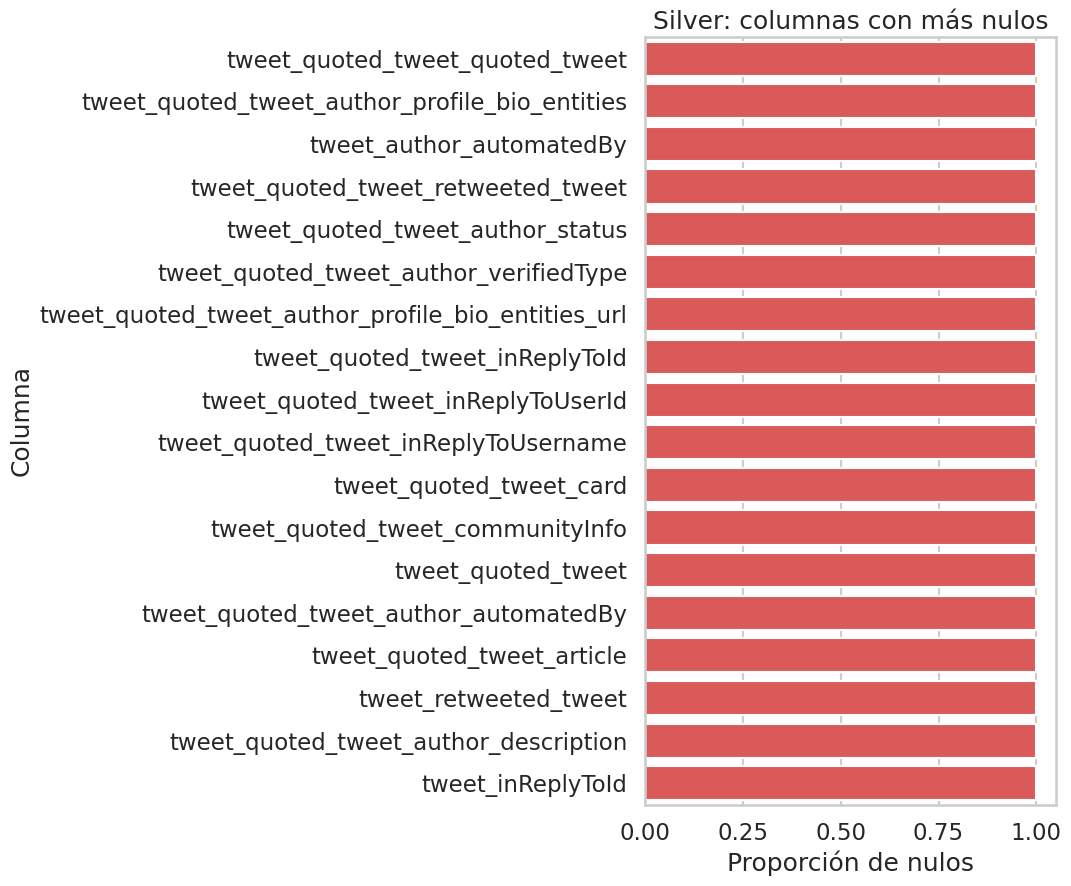

,rows
has_text,
True,1409
False,15


,record_type,rows,text_ratio
0,news,48,1.000000
1,news_comment,941,1.000000
2,tweet,435,0.965517


,metric,value
0,rows with text,1409.000000
1,rows without text,15.000000
2,non-empty text ratio,0.989466
3,unique record_type values,3.000000


In [12]:
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None


def plot_missingness(df: pd.DataFrame, top_n: int = 18, title: str = 'Missingness') -> None:
    missing = df.isna().mean().sort_values(ascending=False).head(top_n).iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.4 * len(missing) + 2)))
    if sns is not None:
        sns.barplot(x=missing.values, y=missing.index, color='#ef4444')
    else:
        plt.barh(missing.index, missing.values, color='#ef4444')
    plt.title(title)
    plt.xlabel('Proporción de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()


silver_df = silver_df.copy()
if 'createdAt' in silver_df.columns:
    silver_df['createdAt'] = pd.to_datetime(silver_df['createdAt'], errors='coerce', format='mixed')
if 'updatedAt' in silver_df.columns:
    silver_df['updatedAt'] = pd.to_datetime(silver_df['updatedAt'], errors='coerce', format='mixed')
if 'parsed_datetime' in silver_df.columns:
    silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce', format='mixed')
if 'event_date' in silver_df.columns:
    silver_df['event_date'] = pd.to_datetime(silver_df['event_date'], errors='coerce', format='mixed')

silver_numeric_candidates = [
    'tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount',
    'tweet_viewCount', 'tweet_author_followers', 'tweet_author_following',
    'tweet_author_mediaCount', 'tweet_author_favouritesCount', 'text_length', 'clean_text_length'
]
silver_numeric_cols = [column for column in silver_numeric_candidates if column in silver_df.columns]

display(Markdown('## Silver: patrones, cobertura y candidatos\n\nQué se puede confiar, qué es escaso y qué estructuras sí merecen llegar a Gold.'))
plot_missingness(silver_df, top_n=18, title='Silver: columnas con más nulos')

if 'has_text' in silver_df.columns:
    display(silver_df['has_text'].value_counts(dropna=False).to_frame('rows'))

if 'record_type' in silver_df.columns:
    display(silver_df.groupby('record_type').agg(rows=('record_type', 'size'), text_ratio=('has_text', 'mean') if 'has_text' in silver_df.columns else ('record_type', 'size')).reset_index())

silver_cleanliness = pd.DataFrame({
    'metric': ['rows with text', 'rows without text', 'non-empty text ratio', 'unique record_type values'],
    'value': [
        int(silver_df['has_text'].sum()) if 'has_text' in silver_df.columns else 0,
        int((~silver_df['has_text']).sum()) if 'has_text' in silver_df.columns else 0,
        float(silver_df['has_text'].mean()) if 'has_text' in silver_df.columns else 0.0,
        int(silver_df['record_type'].nunique(dropna=True)) if 'record_type' in silver_df.columns else 0,
    ]
})
display(silver_cleanliness)


### Lectura ejecutiva del gráfico de Silver

- **Hallazgo principal:** el gráfico muestra qué columnas concentran la mayor proporción de nulos, y ahí se ve qué parte del Silver es realmente utilizable para Gold.
- **Dato relevante:** los campos de texto y `record_type` son la base de la explotación; los bloques más vacíos suelen ser metadatos anidados o campos de contexto más profundo.
- **Decisión:** para la primera versión de Gold, se priorizan texto, tiempo, autor e ինտeracción; lo muy escaso queda como lineage o se descarta si no aporta negocio.

In [13]:
silver_df = silver_df.copy()
silver_df['parsed_datetime'] = pd.to_datetime(silver_df['parsed_datetime'], errors='coerce', format='mixed') if 'parsed_datetime' in silver_df.columns else pd.NaT
silver_df['event_date'] = pd.to_datetime(silver_df['event_date'], errors='coerce', format='mixed') if 'event_date' in silver_df.columns else pd.NaT


def classify_silver_column(column: str, missing_ratio: float) -> dict:
    lower = column.lower()
    family = 'other'
    represents = 'General technical field'
    business_use = 'Review'
    recommendation = 'Review'
    cleaning_action = 'Inspect before use'
    why_it_matters = 'May contain useful context but needs validation.'

    if column in {'_id'}:
        family = 'lineage'
        represents = 'Internal row identifier'
        business_use = 'Traceability'
        recommendation = 'Keep as lineage'
        cleaning_action = 'No cleaning needed'
        why_it_matters = 'Stable source row id.'
    elif column in {'source_file', 'source_group'}:
        family = 'lineage'
        represents = 'File or source batch name'
        business_use = 'Traceability and batch analysis'
        recommendation = 'Keep as lineage'
        cleaning_action = 'Standardize file naming only if needed'
        why_it_matters = 'Explains which batch produced the row.'
    elif column == 'record_type':
        family = 'grain'
        represents = 'Type of row: tweet, news, or news_comment'
        business_use = 'Primary dataset grain'
        recommendation = 'Keep'
        cleaning_action = 'Normalize categories'
        why_it_matters = 'Separates the three analytical layers.'
    elif column in {'createdAt', 'updatedAt', 'parsed_datetime', 'event_date', 'date'}:
        family = 'time'
        represents = 'Timestamp or event date'
        business_use = 'Trend analysis and refresh tracking'
        recommendation = 'Keep'
        cleaning_action = 'Parse consistently and keep one canonical event date'
        why_it_matters = 'Lets us trend perception over time.'
    elif column in {'raw_text', 'clean_text', 'text_length', 'detected_lang', 'has_text', 'tweet_text', 'comment_text', 'news_comments', 'news_newsLink'}:
        family = 'text_nlp'
        if column == 'news_newsLink':
            represents = 'Article URL linked to the news record'
            business_use = 'Context and article grouping'
            recommendation = 'Keep'
            cleaning_action = 'Validate URL format'
            why_it_matters = 'Useful to group comments by article.'
        else:
            represents = 'Text content or NLP-derived feature'
            business_use = 'Sentiment, topics and QA'
            recommendation = 'Keep'
            cleaning_action = 'Normalize whitespace and preserve raw vs clean text'
            why_it_matters = 'Core input for NLP or QA.'
    elif lower.startswith('tweet_author_'):
        family = 'author'
        represents = 'Tweet author profile attribute'
        business_use = 'Influence, segmentation and credibility'
        recommendation = 'Keep' if not any(k in lower for k in ['profile_bio_entities', 'pinnedtweetids', 'coverpicture', 'profilepicture']) else 'Review'
        cleaning_action = 'Keep core fields, review rich profile blobs'
        why_it_matters = 'Important for influencer and author analysis.'
    elif lower.startswith('tweet_quoted_tweet_quoted_tweet_'):
        family = 'deep_quote'
        represents = 'Quoted tweet nested inside another quoted tweet'
        business_use = 'Rare edge-case context'
        recommendation = 'Drop for Gold'
        cleaning_action = 'Drop unless quote-chain analysis is required'
        why_it_matters = 'Extremely sparse and expensive to maintain.'
    elif lower.startswith('tweet_quoted_tweet_'):
        family = 'quote'
        represents = 'Quoted tweet metadata and content'
        business_use = 'Conversation context and amplification'
        recommendation = 'Review'
        cleaning_action = 'Keep only the fields relevant to quote analysis'
        why_it_matters = 'Useful when quote-tweet behavior matters.'
    elif lower.startswith('tweet_'):
        family = 'tweet'
        represents = 'Tweet-level field'
        business_use = 'Core tweet analysis'
        recommendation = 'Keep' if any(k in lower for k in ['id', 'createdat', 'lang', 'source', 'likecount', 'replycount', 'retweetcount', 'quotecount', 'viewcount', 'isreply', 'conversationid']) else 'Review'
        cleaning_action = 'Cast numeric / boolean types and remove nested blobs if not needed'
        why_it_matters = 'Core tweet signal for Gold.'
    elif lower.startswith('news_'):
        family = 'news'
        represents = 'Web scraping news/article attribute'
        business_use = 'Article context and comment analysis'
        recommendation = 'Keep' if any(k in lower for k in ['id', 'newslink', 'comments', 'createdat']) else 'Review'
        cleaning_action = 'Keep context fields, flatten arrays only when needed'
        why_it_matters = 'Defines the article side of Silver.'

    if missing_ratio > 0.9 and recommendation == 'Keep':
        recommendation = 'Review'
        why_it_matters = 'Coverage is very low, so keep only if the use case is strong.'
    if missing_ratio > 0.95 and recommendation == 'Review' and family in {'quote', 'deep_quote', 'news', 'author'}:
        recommendation = 'Drop for Gold'
        cleaning_action = 'Exclude from first Gold version'
        why_it_matters = 'Very sparse and unlikely to improve the first Gold layer.'

    return {
        'column': column,
        'family': family,
        'represents': represents,
        'business_use': business_use,
        'recommendation': recommendation,
        'cleaning_action': cleaning_action,
        'why_it_matters': why_it_matters,
        'missing_ratio': missing_ratio,
    }


def quality_summary(df: pd.DataFrame, id_col: str | None = None, text_col: str | None = None, date_col: str | None = None) -> pd.DataFrame:
    summary = {
        'rows': len(df),
        'columns': len(df.columns),
        'duplicate_rows': int(df.duplicated().sum()),
        'duplicate_rate': float(df.duplicated().mean()) if len(df) else 0.0,
    }
    if id_col and id_col in df.columns:
        summary['id_null_rate'] = float(df[id_col].isna().mean())
        summary['id_unique_rate'] = float(df[id_col].nunique(dropna=True) / len(df)) if len(df) else 0.0
    if text_col and text_col in df.columns:
        text_series = df[text_col].fillna('').astype('string')
        summary['text_missing_rate'] = float((text_series.str.len() == 0).mean())
        summary['avg_text_length'] = float(text_series.str.len().mean())
    if date_col and date_col in df.columns:
        summary['date_missing_rate'] = float(pd.to_datetime(df[date_col], errors='coerce', format='mixed').isna().mean())
    return pd.DataFrame([summary]).T.rename(columns={0: 'value'})


silver_audit = audit_frame(silver_df)
silver_catalog = pd.DataFrame([
    classify_silver_column(row['column'], float(row['missing_ratio']))
    for _, row in silver_audit.iterrows()
]).sort_values(['recommendation', 'missing_ratio', 'column'], ascending=[True, False, True])

silver_quality = quality_summary(silver_df, id_col='_id', text_col='clean_text', date_col='parsed_datetime')
silver_quality['value'] = silver_quality['value'].apply(lambda x: round(float(x), 4) if isinstance(x, (int, float, np.floating)) else x)

silver_family_summary = silver_catalog.groupby(['family', 'recommendation']).size().reset_index(name='columns')

print('Silver quality summary')
display(silver_quality)
print('Silver family summary')
display(silver_family_summary.sort_values(['family', 'recommendation']))
print('Silver column catalog')
display(silver_catalog.head(120))
print('Silver top missing columns')
display(silver_audit.head(20))

Silver quality summary


,value
rows,1424.0000
columns,174.0000
duplicate_rows,0.0000
duplicate_rate,0.0000
id_null_rate,0.0000
id_unique_rate,0.0063
text_missing_rate,0.0105
avg_text_length,419.8567
date_missing_rate,0.0000


Silver family summary


,family,recommendation,columns
0,author,Drop for Gold,7
1,author,Keep,25
2,author,Review,8
3,deep_quote,Drop for Gold,26
4,grain,Keep,1
5,lineage,Keep as lineage,3
6,news,Keep,1
7,other,Review,1
8,quote,Drop for Gold,70
9,text_nlp,Keep,9


Silver column catalog


,column,family,represents,business_use,recommendation,cleaning_action,why_it_matters,missing_ratio
0,tweet_author_automatedBy,author,Tweet author profile attribute,"Influence, segmentation and credibility",Drop for Gold,Exclude from first Gold version,Very sparse and unlikely to improve the first Gold layer.,1.000000
1,tweet_author_description,author,Tweet author profile attribute,"Influence, segmentation and credibility",Drop for Gold,Exclude from first Gold version,Very sparse and unlikely to improve the first Gold layer.,1.000000
2,tweet_author_profile_bio_entities,author,Tweet author profile attribute,"Influence, segmentation and credibility",Drop for Gold,Exclude from first Gold version,Very sparse and unlikely to improve the first Gold layer.,1.000000
3,tweet_author_profile_bio_entities_description,author,Tweet author profile attribute,"Influence, segmentation and credibility",Drop for Gold,Exclude from first Gold version,Very sparse and unlikely to improve the first Gold layer.,1.000000
4,tweet_author_profile_bio_entities_url,author,Tweet author profile attribute,"Influence, segmentation and credibility",Drop for Gold,Exclude from first Gold version,Very sparse and unlikely to improve the first Gold layer.,1.000000
...,...,...,...,...,...,...,...,...
127,tweet_author_isAutomated,author,Tweet author profile attribute,"Influence, segmentation and credibility",Keep,"Keep core fields, review rich profile blobs",Important for influencer and author analysis.,0.705056
128,tweet_author_isBlueVerified,author,Tweet author profile attribute,"Influence, segmentation and credibility",Keep,"Keep core fields, review rich profile blobs",Important for influencer and author analysis.,0.705056
129,tweet_author_isTranslator,author,Tweet author profile attribute,"Influence, segmentation and credibility",Keep,"Keep core fields, review rich profile blobs",Important for influencer and author analysis.,0.705056
130,tweet_author_isVerified,author,Tweet author profile attribute,"Influence, segmentation and credibility",Keep,"Keep core fields, review rich profile blobs",Important for influencer and author analysis.,0.705056


Silver top missing columns


,column,dtype,missing_ratio,non_null_count,nunique
124,tweet_author_automatedBy,float64,1.0,0,0
129,tweet_author_description,float64,1.0,0,0
165,tweet_author_profile_bio_entities,float64,1.0,0,0
164,tweet_author_profile_bio_entities_description,float64,1.0,0,0
162,tweet_author_profile_bio_entities_url,float64,1.0,0,0
153,tweet_author_status,float64,1.0,0,0
159,tweet_author_verifiedType,float64,1.0,0,0
13,tweet_inReplyToId,float64,1.0,0,0
20,tweet_quoted_tweet,float64,1.0,0,0
25,tweet_quoted_tweet_article,float64,1.0,0,0


## Bronze: Column Dictionary and Business Interpretation

Aquí explicamos columna por columna qué representa, por qué existe, si aporta valor a Gold y qué limpieza requiere antes de modelar.

## Bronze: Patterns, Quality and Model-Ready Signals

Ahora miramos qué nos dice el Bronze en términos de volumen, idioma, autores, engagement y consistencia de campos. Esto nos ayuda a decidir qué columnas sí alimentan Gold y cuáles son solo metadatos operativos.

## Bronze: patrones y señales de calidad

Qué señales aportan valor y cuáles son lineage o ruido.

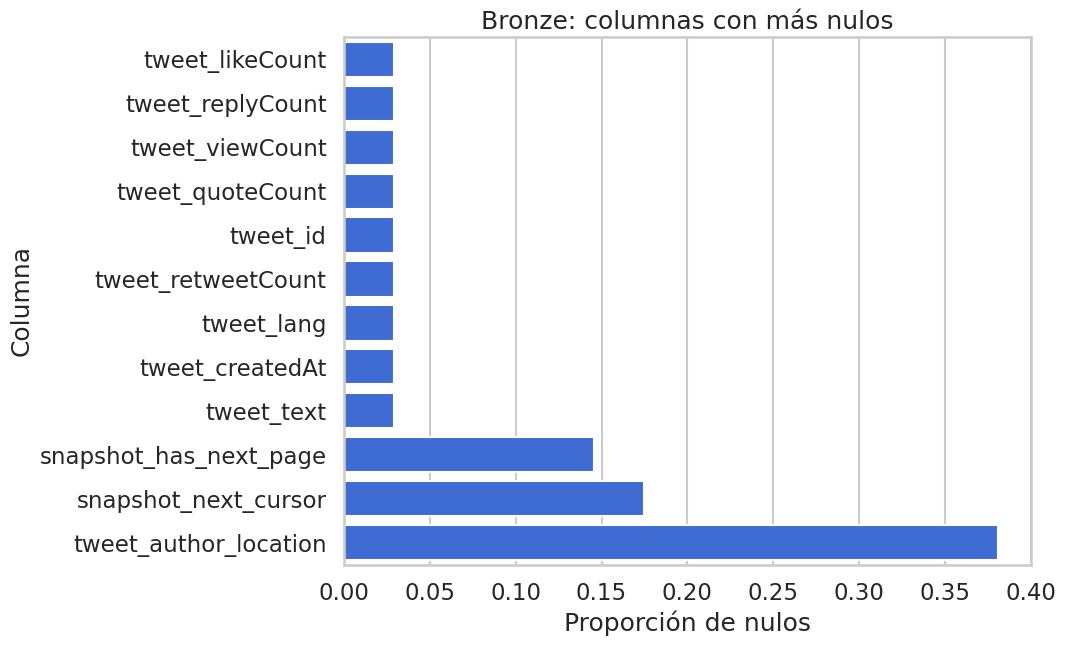

,metric,missing_ratio,mean,median,p95
5,tweet_author_followers,0.029126,4107.125000,295.0,14119.0
4,tweet_viewCount,0.029126,3420.542500,74.0,20461.0
6,tweet_author_following,0.029126,1140.477500,230.5,5153.0
7,text_length,0.000000,304.985437,238.0,942.0
2,tweet_likeCount,0.029126,31.650000,1.0,115.1
1,tweet_replyCount,0.029126,2.965000,0.0,36.0
0,tweet_retweetCount,0.029126,1.435000,0.0,14.0
3,tweet_quoteCount,0.029126,0.135000,0.0,1.0


,metric,value
0,rows,412.0
1,columns,32.0
2,duplicate_rows,0.0
3,tweet_text_raw_equals_tweet_text_ratio,1.0


In [14]:
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None


def section(title: str, subtitle: str | None = None) -> None:
    lines = [f'## {title}']
    if subtitle:
        lines.append(subtitle)
    display(Markdown('\n\n'.join(lines)))


def plot_missingness(df: pd.DataFrame, top_n: int = 12, title: str = '') -> None:
    missing = df.isna().mean().sort_values(ascending=False).head(top_n).iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.4 * len(missing) + 2)))
    if sns is not None:
        sns.barplot(x=missing.values, y=missing.index, color='#2563eb')
    else:
        plt.barh(missing.index, missing.values, color='#2563eb')
    plt.title(title or 'Columnas con más nulos')
    plt.xlabel('Proporción de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()


bronze_df = bronze_df.copy()
bronze_df['tweet_createdAt'] = pd.to_datetime(bronze_df['tweet_createdAt'], errors='coerce', format='mixed')
bronze_df['tweet_day'] = bronze_df['tweet_createdAt'].dt.date.astype('string')

bronze_numeric_cols = [
    'tweet_retweetCount', 'tweet_replyCount', 'tweet_likeCount', 'tweet_quoteCount',
    'tweet_viewCount', 'tweet_author_followers', 'tweet_author_following', 'text_length',
]
bronze_numeric_cols = [column for column in bronze_numeric_cols if column in bronze_df.columns]

section('Bronze: patrones y señales de calidad', 'Qué señales aportan valor y cuáles son lineage o ruido.')
plot_missingness(bronze_df, top_n=12, title='Bronze: columnas con más nulos')

if bronze_numeric_cols:
    engagement_summary = pd.DataFrame({
        'metric': bronze_numeric_cols,
        'missing_ratio': [float(bronze_df[column].isna().mean()) for column in bronze_numeric_cols],
        'mean': [float(pd.to_numeric(bronze_df[column], errors='coerce').mean()) for column in bronze_numeric_cols],
        'median': [float(pd.to_numeric(bronze_df[column], errors='coerce').median()) for column in bronze_numeric_cols],
        'p95': [float(pd.to_numeric(bronze_df[column], errors='coerce').quantile(0.95)) for column in bronze_numeric_cols],
    })
    display(engagement_summary.sort_values('mean', ascending=False))

bronze_quality = pd.DataFrame({
    'metric': ['rows', 'columns', 'duplicate_rows', 'tweet_text_raw_equals_tweet_text_ratio'],
    'value': [
        len(bronze_df),
        len(bronze_df.columns),
        int(bronze_df.duplicated().sum()),
        float((bronze_df['tweet_text'].fillna('') == bronze_df['tweet_text_raw'].fillna('')).mean()) if 'tweet_text' in bronze_df.columns and 'tweet_text_raw' in bronze_df.columns else 0.0,
    ]
})
display(bronze_quality)


### Lectura ejecutiva del gráfico de Bronze

- **Hallazgo principal:** la mayor concentración de nulos marca qué campos son metadatos y cuáles sí sostienen el análisis de percepción.
- **Dato relevante:** el texto y las señales de interacción siguen siendo el núcleo útil; lo demás sirve más para auditoría o trazabilidad.
- **Decisión:** Gold debe conservar una sola versión del texto, la fecha canónica y las métricas que expliquen alcance, reacción y contexto.

In [15]:
bronze_df, silver_df = ensure_loaded()
bronze_df = add_datetime_features(bronze_df, 'tweet_createdAt', 'tweet_event_date')

bronze_catalog = pd.DataFrame([
    {'column': 'snapshot_bronze_file', 'represents': 'Bronze file name that produced the row', 'business_use': 'Lineage and traceability', 'recommendation': 'Keep as lineage', 'cleaning_action': 'No cleaning needed', 'why_it_matters': 'Lets us explain where each row came from.'},
    {'column': 'snapshot__id', 'represents': 'Internal snapshot identifier from the Bronze extraction', 'business_use': 'Technical traceability', 'recommendation': 'Keep as lineage', 'cleaning_action': 'No cleaning needed', 'why_it_matters': 'Useful for audits, not usually for modeling.'},
    {'column': 'snapshot_has_next_page', 'represents': 'Whether the original ingestion still had more pages', 'business_use': 'Extraction QA', 'recommendation': 'Drop from Gold', 'cleaning_action': 'Keep only in raw/bronze', 'why_it_matters': 'Operational metadata, not analytical signal.'},
    {'column': 'snapshot_next_cursor', 'represents': 'Pagination cursor used to continue extraction', 'business_use': 'Extraction QA', 'recommendation': 'Drop from Gold', 'cleaning_action': 'Drop after ingestion', 'why_it_matters': 'Pure process metadata.'},
    {'column': 'tweet_id', 'represents': 'Unique tweet identifier', 'business_use': 'Primary business key for tweet-level analysis', 'recommendation': 'Keep', 'cleaning_action': 'Validate uniqueness and nulls', 'why_it_matters': 'Main join key for tweet-level Gold.'},
    {'column': 'tweet_text', 'represents': 'Original tweet body as extracted', 'business_use': 'NLP source text', 'recommendation': 'Keep only one raw text field', 'cleaning_action': 'Compare with tweet_text_raw and avoid duplication', 'why_it_matters': 'Source text for sentiment and topic analysis.'},
    {'column': 'tweet_createdAt', 'represents': 'Tweet publication timestamp', 'business_use': 'Trend, seasonality, time series', 'recommendation': 'Keep', 'cleaning_action': 'Parse as datetime and standardize timezone', 'why_it_matters': 'Needed for daily/weekly brand perception trends.'},
    {'column': 'tweet_lang', 'represents': 'Language reported by the source', 'business_use': 'Language filtering and QA', 'recommendation': 'Keep', 'cleaning_action': 'Normalize codes and compare with detected_lang', 'why_it_matters': 'Helps verify whether text is analyzable.'},
    {'column': 'tweet_source', 'represents': 'Platform/app used to publish the tweet', 'business_use': 'Channel segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Normalize categories if needed', 'why_it_matters': 'Shows how people publish and from which client.'},
    {'column': 'tweet_retweetCount', 'represents': 'Number of retweets', 'business_use': 'Reach / amplification', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, inspect outliers', 'why_it_matters': 'Measures virality and diffusion.'},
    {'column': 'tweet_replyCount', 'represents': 'Number of replies', 'business_use': 'Conversation depth', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, inspect zeros and spikes', 'why_it_matters': 'Shows conversation intensity.'},
    {'column': 'tweet_likeCount', 'represents': 'Number of likes', 'business_use': 'Engagement / approval', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric, use log scale for visuals', 'why_it_matters': 'Approximate signal of positive reception.'},
    {'column': 'tweet_quoteCount', 'represents': 'Number of quote tweets', 'business_use': 'Amplification with commentary', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric', 'why_it_matters': 'Useful to study polarized or influential posts.'},
    {'column': 'tweet_viewCount', 'represents': 'Number of views', 'business_use': 'Exposure', 'recommendation': 'Keep if populated', 'cleaning_action': 'Inspect missingness and magnitude', 'why_it_matters': 'Lets us normalize engagement by exposure.'},
    {'column': 'tweet_isReply', 'represents': 'Whether the tweet is a reply', 'business_use': 'Conversation role', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Separates original posts from reactions.'},
    {'column': 'tweet_conversationId', 'represents': 'Thread/conversation identifier', 'business_use': 'Thread analysis', 'recommendation': 'Keep', 'cleaning_action': 'Validate format', 'why_it_matters': 'Allows grouping replies inside conversations.'},
    {'column': 'tweet_author_userName', 'represents': 'Author handle', 'business_use': 'Author segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Normalize case and trim spaces', 'why_it_matters': 'Needed to identify users and compare activity.'},
    {'column': 'tweet_author_name', 'represents': 'Display name of the author', 'business_use': 'Human-readable identity', 'recommendation': 'Keep', 'cleaning_action': 'Fill missing with handle when needed', 'why_it_matters': 'Improves readability of outputs and dashboards.'},
    {'column': 'tweet_author_id', 'represents': 'Author unique id', 'business_use': 'Author deduplication', 'recommendation': 'Keep', 'cleaning_action': 'Check duplicates and nulls', 'why_it_matters': 'Stable identifier for author-level analysis.'},
    {'column': 'tweet_author_followers', 'represents': 'Followers of the author', 'business_use': 'Influence / reach proxy', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric and cap outliers if needed', 'why_it_matters': 'Helps identify influential accounts.'},
    {'column': 'tweet_author_following', 'represents': 'Accounts followed by the author', 'business_use': 'Account profile depth', 'recommendation': 'Keep', 'cleaning_action': 'Cast to numeric', 'why_it_matters': 'Useful for spam/behavior patterns.'},
    {'column': 'tweet_author_isVerified', 'represents': 'Verified status flag', 'business_use': 'Credibility segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Separate verified from non-verified voices.'},
    {'column': 'tweet_author_isBlueVerified', 'represents': 'Blue verification flag', 'business_use': 'Credibility segmentation', 'recommendation': 'Keep', 'cleaning_action': 'Convert to boolean', 'why_it_matters': 'Captures current X/Twitter verification behavior.'},
    {'column': 'tweet_author_location', 'represents': 'Declared location of the author', 'business_use': 'Geographic context', 'recommendation': 'Review', 'cleaning_action': 'Standardize only if location analysis is needed', 'why_it_matters': 'Often sparse or noisy, but useful for regional studies.'},
    {'column': 'tweet_author_createdAt', 'represents': 'Account creation date', 'business_use': 'Account age / maturity', 'recommendation': 'Keep', 'cleaning_action': 'Parse as datetime', 'why_it_matters': 'Can highlight new vs mature accounts.'},
    {'column': 'tweet_text_raw', 'represents': 'Raw text preserved for NLP and QA', 'business_use': 'Source text for cleaning', 'recommendation': 'Keep', 'cleaning_action': 'Deduplicate against tweet_text if identical', 'why_it_matters': 'Auditability and reproducible NLP.'},
    {'column': 'clean_text', 'represents': 'Cleaned text ready for NLP', 'business_use': 'Sentiment and topic modeling', 'recommendation': 'Keep', 'cleaning_action': 'Remove URLs, mentions, duplicated whitespace', 'why_it_matters': 'Core input for NLP.'},
    {'column': 'text_length', 'represents': 'Length of cleaned text', 'business_use': 'Quality and feature engineering', 'recommendation': 'Keep', 'cleaning_action': 'Inspect outliers', 'why_it_matters': 'Useful as a proxy for verbosity and spam.'},
    {'column': 'detected_lang', 'represents': 'Language inferred from clean text', 'business_use': 'Language QA and filtering', 'recommendation': 'Keep', 'cleaning_action': 'Compare with tweet_lang', 'why_it_matters': 'Confirms whether the text is analyzable.'},
    {'column': 'is_english', 'represents': 'Boolean flag for English analysis', 'business_use': 'Subset selection for NLP', 'recommendation': 'Keep as QA flag', 'cleaning_action': 'Use only if the model is English-only', 'why_it_matters': 'Supports controlled language filtering.'},
    {'column': 'lang_match', 'represents': 'Whether source language and detected language match', 'business_use': 'Data quality check', 'recommendation': 'Keep as QA flag', 'cleaning_action': 'Interpret as quality indicator', 'why_it_matters': 'Flags uncertain or noisy rows.'},
])

bronze_quality = quality_summary(bronze_df, id_col='tweet_id', text_col='clean_text', date_col='tweet_createdAt')
bronze_duplicate_check = pd.DataFrame([
    {
        'check': 'tweet_text_vs_tweet_text_raw_equal_ratio',
        'value': safe_ratio((bronze_df['tweet_text'].fillna('') == bronze_df['tweet_text_raw'].fillna('')).sum(), len(bronze_df)),
    },
    {
        'check': 'tweet_text_raw_null_rate',
        'value': float(bronze_df['tweet_text_raw'].isna().mean()),
    },
    {
        'check': 'clean_text_null_or_empty_rate',
        'value': float((bronze_df['clean_text'].fillna('').astype('string').str.len() == 0).mean()),
    },
])

print('Bronze quality summary')
display(bronze_quality)
print('Bronze column dictionary')
display(bronze_catalog)
print('Bronze text duplication checks')
display(bronze_duplicate_check)
print('Bronze top missing columns')
display(audit_frame(bronze_df).head(12))

Bronze quality summary


,value
rows,412.000000
columns,33.000000
duplicate_rows,0.000000
duplicate_rate,0.000000
id_null_rate,0.029126
id_unique_rate,0.257282
text_missing_rate,0.029126
avg_text_length,304.868932
date_missing_rate,0.029126


Bronze column dictionary


,column,represents,business_use,recommendation,cleaning_action,why_it_matters
0,snapshot_bronze_file,Bronze file name that produced the row,Lineage and traceability,Keep as lineage,No cleaning needed,Lets us explain where each row came from.
1,snapshot__id,Internal snapshot identifier from the Bronze extraction,Technical traceability,Keep as lineage,No cleaning needed,"Useful for audits, not usually for modeling."
2,snapshot_has_next_page,Whether the original ingestion still had more pages,Extraction QA,Drop from Gold,Keep only in raw/bronze,"Operational metadata, not analytical signal."
3,snapshot_next_cursor,Pagination cursor used to continue extraction,Extraction QA,Drop from Gold,Drop after ingestion,Pure process metadata.
4,tweet_id,Unique tweet identifier,Primary business key for tweet-level analysis,Keep,Validate uniqueness and nulls,Main join key for tweet-level Gold.
5,tweet_text,Original tweet body as extracted,NLP source text,Keep only one raw text field,Compare with tweet_text_raw and avoid duplication,Source text for sentiment and topic analysis.
6,tweet_createdAt,Tweet publication timestamp,"Trend, seasonality, time series",Keep,Parse as datetime and standardize timezone,Needed for daily/weekly brand perception trends.
7,tweet_lang,Language reported by the source,Language filtering and QA,Keep,Normalize codes and compare with detected_lang,Helps verify whether text is analyzable.
8,tweet_source,Platform/app used to publish the tweet,Channel segmentation,Keep,Normalize categories if needed,Shows how people publish and from which client.
9,tweet_retweetCount,Number of retweets,Reach / amplification,Keep,"Cast to numeric, inspect outliers",Measures virality and diffusion.


Bronze text duplication checks


,check,value
0,tweet_text_vs_tweet_text_raw_equal_ratio,1.000000
1,tweet_text_raw_null_rate,0.029126
2,clean_text_null_or_empty_rate,0.029126


Bronze top missing columns


,column,dtype,missing_ratio,non_null_count,nunique
23,tweet_author_location,str,0.381068,255,67
3,snapshot_next_cursor,str,0.174757,340,4
2,snapshot_has_next_page,object,0.145631,352,2
26,clean_text,str,0.029126,400,105
24,tweet_author_createdAt,str,0.029126,400,104
19,tweet_author_followers,float64,0.029126,400,112
20,tweet_author_following,float64,0.029126,400,114
18,tweet_author_id,float64,0.029126,400,104
22,tweet_author_isBlueVerified,object,0.029126,400,2
21,tweet_author_isVerified,object,0.029126,400,1


In [16]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
try:
    import seaborn as sns
except ImportError:
    sns = None

from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

if sns is not None:
    sns.set_theme(style='whitegrid', context='talk')

pd.set_option('display.max_columns', 250)
pd.set_option('display.max_colwidth', 120)


def ensure_loaded() -> tuple[pd.DataFrame, pd.DataFrame]:
    global bronze_df, silver_df
    if 'bronze_df' not in globals():
        bronze_df = load_csv(BRONZE_EDA_CSV)
    if 'silver_df' not in globals():
        silver_df = load_csv(SILVER_EDA_CSV)
    return bronze_df, silver_df



def add_datetime_features(df: pd.DataFrame, column: str, target_name: str) -> pd.DataFrame:
    result = df.copy()
    if column in result.columns:
        result[column] = pd.to_datetime(result[column], errors='coerce', format='mixed')
        result[target_name] = result[column].dt.date.astype('string')
    return result



def section(title: str, subtitle: str | None = None) -> None:
    lines = [f'## {title}']
    if subtitle:
        lines.append(subtitle)
    display(Markdown('\n\n'.join(lines)))



def audit_frame(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_ratio': df.isna().mean().values,
        'non_null_count': df.notna().sum().values,
        'nunique': [df[col].nunique(dropna=True) for col in df.columns],
    }).sort_values(['missing_ratio', 'column'], ascending=[False, True])



def quality_summary(df: pd.DataFrame, id_col: str | None = None, text_col: str | None = None, date_col: str | None = None) -> pd.DataFrame:
    summary = {
        'rows': len(df),
        'columns': len(df.columns),
        'duplicate_rows': int(df.duplicated().sum()),
        'duplicate_rate': float(df.duplicated().mean()) if len(df) else 0.0,
    }
    if id_col and id_col in df.columns:
        summary['id_null_rate'] = float(df[id_col].isna().mean())
        summary['id_unique_rate'] = float(df[id_col].nunique(dropna=True) / len(df)) if len(df) else 0.0
    if text_col and text_col in df.columns:
        text_series = df[text_col].fillna('').astype('string')
        summary['text_missing_rate'] = float((text_series.str.len() == 0).mean())
        summary['avg_text_length'] = float(text_series.str.len().mean())
    if date_col and date_col in df.columns:
        summary['date_missing_rate'] = float(pd.to_datetime(df[date_col], errors='coerce', format='mixed').isna().mean())
    return pd.DataFrame([summary]).T.rename(columns={0: 'value'})



def top_values(df: pd.DataFrame, column: str, n: int = 10) -> pd.DataFrame:
    if column not in df.columns:
        return pd.DataFrame()
    return df[column].fillna('Unknown').value_counts(dropna=False).head(n).to_frame('rows')



def plot_missingness(df: pd.DataFrame, top_n: int = 15, title: str = '') -> None:
    audit = audit_frame(df).head(top_n).iloc[::-1]
    plt.figure(figsize=(11, max(5, 0.4 * len(audit) + 2)))
    if sns is not None:
        sns.barplot(data=audit, x='missing_ratio', y='column', color='#2563eb')
    else:
        plt.barh(audit['column'], audit['missing_ratio'], color='#2563eb')
    plt.title(title or 'Columnas con más nulos')
    plt.xlabel('Proporción de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()



def plot_numeric_corr(df: pd.DataFrame, columns: list[str], title: str = '') -> None:
    numeric = [column for column in columns if column in df.columns]
    if len(numeric) < 2:
        print('No hay suficientes columnas numéricas para calcular la correlación.')
        return

    numeric_df = df[numeric].apply(pd.to_numeric, errors='coerce')
    corr = numeric_df.corr(numeric_only=True).round(2)
    if corr.empty:
        print('La matriz de correlación está vacía.')
        return

    label_map = {
        'tweet_retweetCount': 'rt',
        'tweet_replyCount': 'rep',
        'tweet_likeCount': 'like',
        'tweet_quoteCount': 'quote',
        'tweet_viewCount': 'views',
        'tweet_author_followers': 'followers',
        'tweet_author_following': 'following',
        'tweet_author_mediaCount': 'media',
        'tweet_author_favouritesCount': 'favs',
        'text_length': 'txt_len',
        'clean_text_length': 'clean_len',
    }
    corr.columns = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.columns]
    corr.index = [label_map.get(column, column.replace('tweet_', '').replace('author_', 'auth_')) for column in corr.index]

    mask = np.triu(np.ones_like(corr, dtype=bool))
    size = max(7.0, 0.85 * len(corr.columns) + 3.0)
    annot = len(corr.columns) <= 12

    plt.figure(figsize=(size, size))
    if sns is not None:
        sns.heatmap(
            corr,
            mask=mask,
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.6,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            annot=annot,
            fmt='.2f',
            annot_kws={'size': 8},
        )
    else:
        masked = np.ma.masked_where(mask, corr.values)
        plt.imshow(masked, cmap='RdBu_r', vmin=-1, vmax=1)
        plt.colorbar(label='Correlación', shrink=0.8)
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=35, ha='right')
        plt.yticks(range(len(corr.index)), corr.index)

    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.title(title or 'Matriz de correlación')
    plt.tight_layout()
    plt.show()



def plot_top_categories(df: pd.DataFrame, column: str, top_n: int = 10, title: str = '') -> None:
    if column not in df.columns:
        print(f'{column} no existe en el dataframe.')
        return
    values = df[column].fillna('Unknown').value_counts(dropna=False).head(top_n).sort_values()
    plt.figure(figsize=(11, max(5, 0.4 * len(values) + 2)))
    if sns is not None:
        sns.barplot(x=values.values, y=values.index, color='#0f766e')
    else:
        plt.barh(values.index, values.values, color='#0f766e')
    plt.title(title or f'Top {top_n} valores para {column}')
    plt.xlabel('Registros')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()



def plot_time_series(df: pd.DataFrame, date_col: str, title: str = '') -> None:
    if date_col not in df.columns:
        print(f'{date_col} no existe en el dataframe.')
        return
    series = pd.to_datetime(df[date_col], errors='coerce', format='mixed').dt.date.value_counts().sort_index()
    if series.empty:
        print(f'No hay fechas válidas en {date_col}.')
        return
    plt.figure(figsize=(12, 5))
    plt.plot(series.index, series.values, marker='o', color='#7c3aed')
    plt.title(title or f'Volumen en el tiempo por {date_col}')
    plt.xlabel('Fecha')
    plt.ylabel('Registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



def safe_ratio(numerator: int, denominator: int) -> float:
    return float(numerator / denominator) if denominator else 0.0

## Identidad, duplicados e higiene de unión

Antes de unir, se debe confirmar qué identificadores son realmente únicos y cuáles se repiten por diseño. Ese paso evita joins inflados y métricas inconsistentes.

In [17]:
bronze_df, silver_df = ensure_loaded()

bronze_id_counts = bronze_df['tweet_id'].fillna('missing').value_counts().reset_index()
bronze_id_counts.columns = ['tweet_id', 'rows']
bronze_duplicate_ids = bronze_id_counts[bronze_id_counts['rows'] > 1]
bronze_duplicate_share = safe_ratio(int(bronze_duplicate_ids['rows'].sum()), len(bronze_df)) if len(bronze_df) else 0.0

print(f'Bronze rows with duplicated tweet_id: {len(bronze_duplicate_ids)}')
print(f'Bronze duplicated-row share: {bronze_duplicate_share:.4f}')
display(bronze_id_counts.head(15))

gold_join_rules = pd.DataFrame([
    {
        'entity': 'tweet',
        'identifier': 'tweet_id',
        'recommended_grain': 'one row per tweet',
        'dedup_rule': 'keep latest snapshot by tweet_createdAt or latest source_file batch',
        'join_note': 'Do not join Bronze row-by-row without deduplicating repeated tweet_id values.'
    },
    {
        'entity': 'news_comment',
        'identifier': 'news__id + comment text',
        'recommended_grain': 'one row per comment',
        'dedup_rule': 'keep all comments but remove exact duplicates after flattening',
        'join_note': 'Use Silver as the article/comment layer, not Bronze.'
    },
    {
        'entity': 'daily_brand_summary',
        'identifier': 'event_date + brand/topic',
        'recommended_grain': 'one row per date per brand/topic',
        'dedup_rule': 'aggregate from tweet and comment tables',
        'join_note': 'Best layer for dashboards and business reporting.'
    },
])

display(gold_join_rules)

display(Markdown(
    f"**Conclusión ejecutiva de higiene:** Bronze repite `tweet_id` entre snapshots, así que la deduplicación por identidad del tweet es obligatoria antes de unir. "
    f"En Silver, `_id` funciona como lineage, no como llave de negocio. La construcción correcta es por entidades y luego por agregaciones."
))

Bronze rows with duplicated tweet_id: 47
Bronze duplicated-row share: 0.8544


,tweet_id,rows
0,2042444537281593856.0,13
1,2042356352027410944.0,13
2,2041877436258726400.0,13
3,2043651774498640384.0,12
4,2043421390402134272.0,12
5,2043354333920526848.0,12
6,missing,12
7,2041654754456302080.0,9
8,2041072528534495488.0,9
9,2040818038887338240.0,9


,entity,identifier,recommended_grain,dedup_rule,join_note
0,tweet,tweet_id,one row per tweet,keep latest snapshot by tweet_createdAt or latest source_file batch,Do not join Bronze row-by-row without deduplicating repeated tweet_id values.
1,news_comment,news__id + comment text,one row per comment,keep all comments but remove exact duplicates after flattening,"Use Silver as the article/comment layer, not Bronze."
2,daily_brand_summary,event_date + brand/topic,one row per date per brand/topic,aggregate from tweet and comment tables,Best layer for dashboards and business reporting.


**Conclusión ejecutiva de higiene:** Bronze repite `tweet_id` entre snapshots, así que la deduplicación por identidad del tweet es obligatoria antes de unir. En Silver, `_id` funciona como lineage, no como llave de negocio. La construcción correcta es por entidades y luego por agregaciones.

### Lectura ejecutiva de la higiene de unión

- **Hallazgo principal:** Bronze repite `tweet_id` entre snapshots, así que no es válido unir fila por fila.
- **Dato relevante:** la versión útil para análisis debe conservarse por identidad del tweet y no por captura técnica.
- **Decisión:** la lineage queda para auditoría; el grano analítico se define con la última versión útil por entidad.

## Construcción del Gold final

En este cierre se materializa la decisión analítica en una arquitectura híbrida de Gold. En lugar de una sola tabla, se generan capas complementarias: una canónica por tweet, una histórica por snapshot, una multimodal por tipo de registro y un agregado diario para dashboard.

In [2]:
# Gold v2: salidas híbridas para maximizar volumen sin mezclar granos
# - gold_tweets_latest.csv: 1 fila por tweet_id (canónica para reporting)
# - gold_tweets_snapshots.csv: historial completo de snapshots por tweet
# - gold_multimodal_records.csv: todos los registros Silver (tweet/news/news_comment)
# - gold_brand_daily.csv: agregados diarios para dashboard

from pathlib import Path


def _resolve_project_paths() -> tuple[Path, Path, Path]:
    if 'PROJECT_ROOT' in globals() and 'NOTEBOOK_OUTPUT' in globals():
        project_root = PROJECT_ROOT
        output_dir = NOTEBOOK_OUTPUT
    else:
        cwd = Path.cwd()
        project_root = cwd
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
                project_root = candidate
                break
        output_dir = project_root / 'notebooks' / 'output'

    bronze_path = output_dir / 'bronze_twitter_eda.csv'
    silver_path = output_dir / 'silver_eda.csv'
    return project_root, output_dir, bronze_path, silver_path


def _load_if_needed() -> tuple[pd.DataFrame, pd.DataFrame, Path]:
    _, output_dir, bronze_path, silver_path = _resolve_project_paths()

    if 'bronze_df' in globals() and isinstance(bronze_df, pd.DataFrame):
        bronze_local = bronze_df.copy()
    else:
        bronze_local = pd.read_csv(bronze_path)

    if 'silver_df' in globals() and isinstance(silver_df, pd.DataFrame):
        silver_local = silver_df.copy()
    else:
        silver_local = pd.read_csv(silver_path)

    output_dir.mkdir(parents=True, exist_ok=True)
    return bronze_local, silver_local, output_dir


def _coerce_datetime(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    result = df.copy()
    for col in columns:
        if col in result.columns:
            result[col] = pd.to_datetime(result[col], errors='coerce', format='mixed')
    return result


def _to_bool(series: pd.Series) -> pd.Series:
    return series.astype('boolean')


bronze_local, silver_local, output_dir = _load_if_needed()

# -------------------------------------------------------------------
# 1) Historial de tweets por snapshot (máximo volumen)
# -------------------------------------------------------------------
bronze_local = _coerce_datetime(bronze_local, ['tweet_createdAt'])
bronze_local['tweet_event_date'] = bronze_local['tweet_createdAt'].dt.date.astype('string') if 'tweet_createdAt' in bronze_local.columns else pd.Series([''] * len(bronze_local), dtype='string')
bronze_local['bronze_completeness'] = bronze_local.notna().sum(axis=1)
bronze_local['bronze_text_length'] = bronze_local['clean_text'].astype('string').str.len() if 'clean_text' in bronze_local.columns else pd.Series([0] * len(bronze_local), dtype='int64')

if 'tweet_id' in bronze_local.columns:
    gold_tweets_snapshots = bronze_local[bronze_local['tweet_id'].notna()].copy()
else:
    gold_tweets_snapshots = bronze_local.copy()

if {'tweet_id', 'tweet_createdAt'}.issubset(gold_tweets_snapshots.columns):
    gold_tweets_snapshots = gold_tweets_snapshots.sort_values(
        by=['tweet_id', 'tweet_createdAt', 'bronze_completeness', 'snapshot_bronze_file'],
        ascending=[True, False, False, True],
        na_position='last',
    )
    gold_tweets_snapshots['tweet_snapshot_rank'] = gold_tweets_snapshots.groupby('tweet_id').cumcount() + 1
else:
    gold_tweets_snapshots['tweet_snapshot_rank'] = 1

for col in ['tweet_retweetCount', 'tweet_replyCount', 'tweet_likeCount', 'tweet_quoteCount', 'tweet_viewCount', 'tweet_author_followers', 'tweet_author_following', 'text_length', 'bronze_completeness', 'bronze_text_length']:
    if col in gold_tweets_snapshots.columns:
        gold_tweets_snapshots[col] = pd.to_numeric(gold_tweets_snapshots[col], errors='coerce')

for col in ['tweet_isReply', 'tweet_author_isVerified', 'tweet_author_isBlueVerified', 'is_english', 'lang_match']:
    if col in gold_tweets_snapshots.columns:
        gold_tweets_snapshots[col] = _to_bool(gold_tweets_snapshots[col])

gold_tweets_snapshots['gold_entity'] = 'tweet'
gold_tweets_snapshots['gold_grain'] = 'snapshot_per_tweet'

# -------------------------------------------------------------------
# 2) Tabla canónica deduplicada (1 fila por tweet_id)
# -------------------------------------------------------------------
if 'tweet_id' in gold_tweets_snapshots.columns:
    gold_tweets_latest = gold_tweets_snapshots.drop_duplicates(subset=['tweet_id'], keep='first').copy()
else:
    gold_tweets_latest = gold_tweets_snapshots.copy()

if 'record_type' in silver_local.columns and 'tweet_id' in silver_local.columns:
    silver_tweets = silver_local[silver_local['record_type'].eq('tweet') & silver_local['tweet_id'].notna()].copy()
    if not silver_tweets.empty:
        silver_tweets['silver_tweet_rows'] = 1
        if 'clean_text' in silver_tweets.columns:
            silver_tweets['silver_text_missing_flag'] = silver_tweets['clean_text'].fillna('').astype('string').str.len().eq(0)
        else:
            silver_tweets['silver_text_missing_flag'] = pd.NA
        silver_tweet_summary = silver_tweets.groupby('tweet_id', dropna=True).agg(
            silver_tweet_rows=('silver_tweet_rows', 'sum'),
            silver_text_missing=('silver_text_missing_flag', 'mean'),
        ).reset_index()
        gold_tweets_latest = gold_tweets_latest.merge(silver_tweet_summary, on='tweet_id', how='left')
    else:
        gold_tweets_latest['silver_tweet_rows'] = pd.NA
        gold_tweets_latest['silver_text_missing'] = pd.NA
else:
    gold_tweets_latest['silver_tweet_rows'] = pd.NA
    gold_tweets_latest['silver_text_missing'] = pd.NA

gold_tweets_latest['gold_entity'] = 'tweet'
gold_tweets_latest['gold_grain'] = 'latest_per_tweet'

# -------------------------------------------------------------------
# 3) Gold multimodal desde Silver (tweet/news/news_comment)
# -------------------------------------------------------------------
silver_local = _coerce_datetime(silver_local, ['parsed_datetime', 'tweet_createdAt', 'createdAt', 'updatedAt', 'event_date'])
gold_multimodal = silver_local.copy()

def _first_available(df: pd.DataFrame, cols: list[str], default_value=pd.NA):
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series([default_value] * len(df), index=df.index)
    result = df[present[0]].copy()
    for col in present[1:]:
        result = result.fillna(df[col])
    return result

gold_multimodal['gold_record_id'] = _first_available(gold_multimodal, ['_id', 'tweet_id', 'news__id'])
gold_multimodal['gold_entity'] = _first_available(gold_multimodal, ['record_type'], default_value='unknown').fillna('unknown').astype('string')
gold_multimodal['gold_event_datetime'] = _first_available(gold_multimodal, ['parsed_datetime', 'tweet_createdAt', 'createdAt', 'updatedAt', 'event_date'])
gold_multimodal['gold_event_datetime'] = pd.to_datetime(gold_multimodal['gold_event_datetime'], errors='coerce', format='mixed')
gold_multimodal['gold_event_date'] = gold_multimodal['gold_event_datetime'].dt.date.astype('string')
gold_multimodal['gold_text_raw'] = _first_available(gold_multimodal, ['raw_text', 'tweet_text', 'comment_text', 'clean_text'])
gold_multimodal['gold_text_clean'] = _first_available(gold_multimodal, ['clean_text', 'raw_text', 'tweet_text', 'comment_text'])
gold_multimodal['gold_has_text'] = gold_multimodal['gold_text_clean'].fillna('').astype('string').str.len().gt(0)
gold_multimodal['gold_has_text'] = _to_bool(gold_multimodal['gold_has_text'])
gold_multimodal['gold_grain'] = 'record_level_multimodal'

gold_multimodal_columns = [
    'gold_record_id', 'gold_entity', 'gold_event_datetime', 'gold_event_date',
    'gold_text_raw', 'gold_text_clean', 'gold_has_text', 'gold_grain',
    '_id', 'tweet_id', 'news__id', 'source_file', 'record_type',
    'tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount',
    'tweet_author_userName', 'tweet_author_name', 'detected_lang', 'has_text',
]
gold_multimodal_columns = [c for c in gold_multimodal_columns if c in gold_multimodal.columns]
gold_multimodal = gold_multimodal[gold_multimodal_columns + [c for c in gold_multimodal.columns if c not in gold_multimodal_columns]].copy()

for col in ['tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount']:
    if col in gold_multimodal.columns:
        gold_multimodal[col] = pd.to_numeric(gold_multimodal[col], errors='coerce')

# -------------------------------------------------------------------
# 4) Agregado diario para dashboard
# -------------------------------------------------------------------
gold_brand_daily = gold_multimodal.copy()

if 'gold_event_date' in gold_brand_daily.columns:
    group_keys = ['gold_event_date', 'gold_entity'] if 'gold_entity' in gold_brand_daily.columns else ['gold_event_date']

    agg_dict = {
        'gold_record_id': ('gold_record_id', 'nunique') if 'gold_record_id' in gold_brand_daily.columns else None,
        'gold_has_text': ('gold_has_text', 'mean') if 'gold_has_text' in gold_brand_daily.columns else None,
    }
    for col in ['tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount']:
        if col in gold_brand_daily.columns:
            agg_dict[f'total_{col}'] = (col, 'sum')

    agg_dict = {k: v for k, v in agg_dict.items() if v is not None}

    if agg_dict:
        gold_brand_daily = gold_brand_daily.groupby(group_keys, dropna=False).agg(**agg_dict).reset_index()
    else:
        gold_brand_daily = gold_brand_daily.groupby(group_keys, dropna=False).size().reset_index(name='rows')

    gold_brand_daily = gold_brand_daily.rename(columns={'gold_record_id': 'unique_records', 'gold_has_text': 'text_coverage_ratio'})
else:
    gold_brand_daily = pd.DataFrame(columns=['gold_event_date', 'gold_entity', 'unique_records', 'text_coverage_ratio'])

# -------------------------------------------------------------------
# Exportaciones
# -------------------------------------------------------------------
path_latest = output_dir / 'gold_tweets_latest.csv'
path_snapshots = output_dir / 'gold_tweets_snapshots.csv'
path_multimodal = output_dir / 'gold_multimodal_records.csv'
path_daily = output_dir / 'gold_brand_daily.csv'
path_compat = output_dir / 'gold_tweets.csv'

gold_tweets_latest.to_csv(path_latest, index=False, encoding='utf-8')
gold_tweets_snapshots.to_csv(path_snapshots, index=False, encoding='utf-8')
gold_multimodal.to_csv(path_multimodal, index=False, encoding='utf-8')
gold_brand_daily.to_csv(path_daily, index=False, encoding='utf-8')

# Compatibilidad hacia atrás: mantiene el nombre histórico
# pero ahora apunta a la versión canónica deduplicada.
gold_tweets_latest.to_csv(path_compat, index=False, encoding='utf-8')

summary = pd.DataFrame([
    {'dataset': 'gold_tweets_latest', 'grain': '1 row per tweet_id', 'rows': len(gold_tweets_latest), 'columns': len(gold_tweets_latest.columns), 'path': str(path_latest)},
    {'dataset': 'gold_tweets_snapshots', 'grain': '1 row per snapshot + tweet_id', 'rows': len(gold_tweets_snapshots), 'columns': len(gold_tweets_snapshots.columns), 'path': str(path_snapshots)},
    {'dataset': 'gold_multimodal_records', 'grain': '1 row per silver record', 'rows': len(gold_multimodal), 'columns': len(gold_multimodal.columns), 'path': str(path_multimodal)},
    {'dataset': 'gold_brand_daily', 'grain': '1 row per date + entity', 'rows': len(gold_brand_daily), 'columns': len(gold_brand_daily.columns), 'path': str(path_daily)},
    {'dataset': 'gold_tweets (compat)', 'grain': 'alias of gold_tweets_latest', 'rows': len(gold_tweets_latest), 'columns': len(gold_tweets_latest.columns), 'path': str(path_compat)},
])

display(Markdown('## Gold v2: validación y exportación (híbrido)'))
display(summary)

print('Archivos Gold generados:')
for p in [path_latest, path_snapshots, path_multimodal, path_daily, path_compat]:
    print(f'- {p}')

if 'tweet_id' in gold_tweets_latest.columns:
    print(f"\nGold latest: tweet_id únicos = {gold_tweets_latest['tweet_id'].nunique(dropna=True)}")
if 'tweet_id' in gold_tweets_snapshots.columns:
    print(f"Gold snapshots: tweet_id únicos = {gold_tweets_snapshots['tweet_id'].nunique(dropna=True)}")
    print(f'Gold snapshots: filas totales = {len(gold_tweets_snapshots)}')
if 'gold_entity' in gold_multimodal.columns:
    print('\nGold multimodal por entidad:')
    print(gold_multimodal['gold_entity'].value_counts(dropna=False).to_string())

## Gold v2: validación y exportación (híbrido)

,dataset,grain,rows,columns,path
0,gold_tweets_latest,1 row per tweet_id,106,39,/home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets_latest.csv
1,gold_tweets_snapshots,1 row per snapshot + tweet_id,400,37,/home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets_snapshots.csv
2,gold_multimodal_records,1 row per silver record,1424,181,/home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_multimodal_records.csv
3,gold_brand_daily,1 row per date + entity,11,9,/home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_brand_daily.csv
4,gold_tweets (compat),alias of gold_tweets_latest,106,39,/home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets.csv


Archivos Gold generados:
- /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets_latest.csv
- /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets_snapshots.csv
- /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_multimodal_records.csv
- /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_brand_daily.csv
- /home/naciscric/Documents/Data-Analysis-Programming/notebooks/output/gold_tweets.csv

Gold latest: tweet_id únicos = 106
Gold snapshots: tweet_id únicos = 106
Gold snapshots: filas totales = 400

Gold multimodal por entidad:
gold_entity
news_comment    941
tweet           435
news             48


### Lectura ejecutiva del Gold final

- **Hallazgo principal:** Gold ya no depende de una sola tabla; ahora combina grano canónico, histórico y multimodal para maximizar cobertura.
- **Dato relevante:** la tabla `latest` mantiene calidad analítica (1 tweet por `tweet_id`), mientras `snapshots` y `multimodal` elevan volumen para exploración, dashboard y app.
- **Decisión:** para consumo de negocio se usa el agregado diario y la tabla canónica; para análisis profundo se usan snapshots y multimodal sin perder trazabilidad.